# PFASGroups fingerprint — chain-length × branching-degree analysis

Systematic study of how fingerprint configurations respond to:
1. **Chain length** — total fluorinated carbons C2–C8
2. **Branching degree** — linear / α-mono / β-mono / γ-mono / gem-di / α+β double

Compares PFASGroups configs (focused on `min_dist_to_barycenter` + `effective_graph_resistance`)
against an overfitted PFCA discriminator (`ideal_PFCA`) — a hand-crafted upper bound
designed to perfectly discriminate exactly this test set.

In [1]:
from __future__ import annotations
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from scipy.spatial import ConvexHull

# Add repo root to sys.path
try:
    NOTEBOOK_DIR = Path(__vsc_ipynb_file__).parent
except NameError:
    try:
        NOTEBOOK_DIR = Path(__file__).parent
    except NameError:
        NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from PFASGroups import parse_smiles
from PFASGroups.fingerprints import PFASFingerprint, FINGERPRINT_PRESETS

warnings.filterwarnings('ignore')
%matplotlib inline
print('Imports OK')
print(f'REPO_ROOT = {REPO_ROOT}')

# Figure registry: populated by each plot cell, saved at cell 25
_SAVED_FIGS: dict = {}

Imports OK
REPO_ROOT = C:\Users\luc\git\PFASGroups


## 1. Molecule grid

All molecules are PFCA (perfluoroalkyl carboxylic acids, `OC(=O)` head group).
The fluorinated tail varies on two axes: chain length (C2–C8) and branching type.

In [2]:
def _cf2(n): return 'C(F)(F)' * n

def linear(n):
    assert n >= 1
    return 'OC(=O)' + _cf2(n - 1) + 'C(F)(F)F'

def alpha(n):
    assert n >= 3
    tail = _cf2(n - 3) + 'C(F)(F)F' if n > 3 else ''
    return 'OC(=O)C(F)(C(F)(F)F)' + (tail if tail else 'F')

def beta(n):
    assert n >= 4
    tail = _cf2(n - 4) + 'C(F)(F)F' if n > 4 else ''
    return 'OC(=O)C(F)(F)C(F)(C(F)(F)F)' + (tail if tail else 'F')

def gamma(n):
    assert n >= 5
    tail = _cf2(n - 5) + 'C(F)(F)F' if n > 5 else ''
    return 'OC(=O)C(F)(F)C(F)(F)C(F)(C(F)(F)F)' + (tail if tail else 'F')

def gem(n):
    assert n >= 4
    tail = _cf2(n - 4) + 'C(F)(F)F' if n > 4 else ''
    return 'OC(=O)C(C(F)(F)F)(C(F)(F)F)' + (tail if tail else 'F')

def double_ab(n):
    assert n >= 5
    tail = _cf2(n - 5) + 'C(F)(F)F' if n > 5 else ''
    return 'OC(=O)C(F)(C(F)(F)F)C(F)(C(F)(F)F)' + (tail if tail else 'F')

BRANCHING_MAKERS = {
    'linear':    (linear,    range(2, 9)),
    'alpha':     (alpha,     range(3, 9)),
    'beta':      (beta,      range(4, 9)),
    'gamma':     (gamma,     range(5, 9)),
    'gem':       (gem,       range(4, 9)),
    'double_ab': (double_ab, range(5, 9)),
}

records = []
for btype, (maker, rng) in BRANCHING_MAKERS.items():
    for n in rng:
        records.append(dict(label=f'C{n}-{btype}', smiles=maker(n),
                            n_fluoro_c=n, branching=btype))
MOL_DF = pd.DataFrame(records)
print(f'{len(MOL_DF)} molecules')
MOL_DF

31 molecules


,label,smiles,n_fluoro_c,branching
0,C2-linear,OC(=O)C(F)(F)C(F)(F)F,2,linear
1,C3-linear,OC(=O)C(F)(F)C(F)(F)C(F)(F)F,3,linear
2,C4-linear,OC(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F,4,linear
3,C5-linear,OC(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F,5,linear
4,C6-linear,OC(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F,6,linear
5,C7-linear,OC(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(...,7,linear
6,C8-linear,OC(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(...,8,linear
7,C3-alpha,OC(=O)C(F)(C(F)(F)F)F,3,alpha
8,C4-alpha,OC(=O)C(F)(C(F)(F)F)C(F)(F)C(F)(F)F,4,alpha
9,C5-alpha,OC(=O)C(F)(C(F)(F)F)C(F)(F)C(F)(F)C(F)(F)F,5,alpha


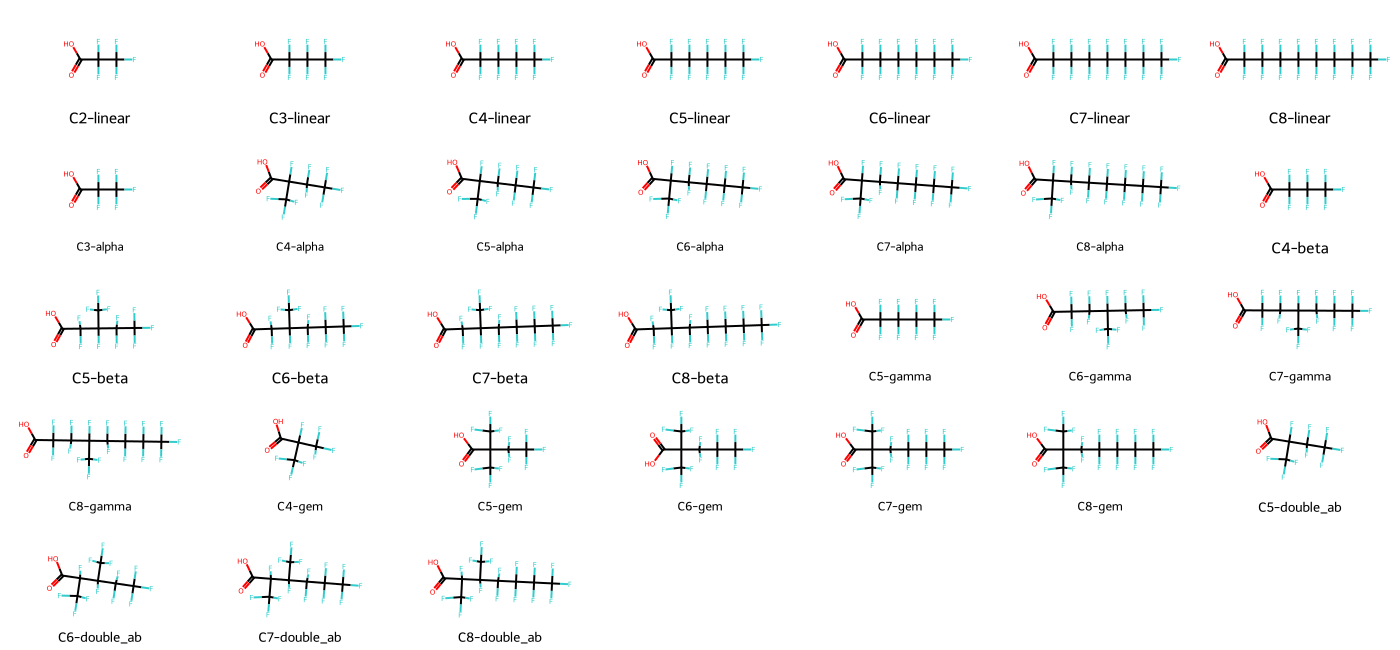

In [3]:
from rdkit import Chem
from rdkit.Chem import Draw
mols = [Chem.MolFromSmiles(s) for s in MOL_DF['smiles']]
labels_list = list(MOL_DF['label'])
img = Draw.MolsToGridImage(mols, molsPerRow=7, subImgSize=(200, 130),
                           legends=labels_list, returnPNG=False)
display(img)

## 2. Fingerprint configurations
Five base configs — `binary`, `total_component`, `egr` (`binary + effective_graph_resistance`),
`mdb` (`binary + min_dist_to_barycenter`), `egr+mdb` — each run with and without molecule-level
metrics (`n_components`, `total_size`, `max_branching`, `max_diameter`), giving **10 configurations** total.

In [4]:
_EGR = 'effective_graph_resistance'
_MDB = 'min_dist_to_barycenter'
_MRB = 'min_resistance_dist_to_barycenter'
_MDC = 'min_dist_to_center'
_MRC = 'min_resistance_dist_to_center'
_MDP = 'min_dist_to_periphery'
_MRP = 'min_resistance_dist_to_periphery'
# Molecule-level metrics appended after group blocks
_MOL_M = ['n_components', 'total_size', 'max_branching', 'max_diameter']

_BASE_CONFIGS = [
    ('binary',     ['binary']),
    ('c',          ['count']),
    ('tc',         ['total_component']),
    ('egr',        [_EGR]),
    ('mdb',        [_MDB]),
    ('egr+mdb',    [_EGR, _MDB]),
    ('mrb',        [_MRB]),
    ('mdc',        [_MDC]),
    ('mdp',        [_MDP]),
    ('mrc',        [_MRC]),
    ('mrp',        [_MRP]),
    ('egr+mdb+tc', [_EGR,_MDB,'total_component']),
    ('egr+mdb+mc', [_EGR,_MDB,'max_component']),
    ('egr+mdb+c',  [_EGR,_MDB,'count']),
    ('egr+mdb+b',  [_EGR,_MDB,'binary']),
    ('egr+mrb+tc', [_EGR,_MRB,'total_component']),
    ('egr+mrb+mc', [_EGR,_MRB,'max_component']),
    ('egr+mrb+c', [_EGR,_MRB,'count']),
    ('egr+mrb+b', [_EGR,_MRB,'binary'])
]

def build_configs():
    cfgs = []
    for lbl, cm in _BASE_CONFIGS:
        cfgs.append(('No mol_metrics',   lbl,
                     dict(component_metrics=list(cm))))
        cfgs.append(('With mol_metrics', lbl + '+mol',
                     dict(component_metrics=list(cm), molecule_metrics=list(_MOL_M))))
    return cfgs

FP_CONFIGS = build_configs()
print(f'{len(FP_CONFIGS)} fingerprint configurations')
pd.DataFrame([(s, l) for s, l, _ in FP_CONFIGS], columns=['section', 'label'])

38 fingerprint configurations


,section,label
0,No mol_metrics,binary
1,With mol_metrics,binary+mol
2,No mol_metrics,c
3,With mol_metrics,c+mol
4,No mol_metrics,tc
5,With mol_metrics,tc+mol
6,No mol_metrics,egr
7,With mol_metrics,egr+mol
8,No mol_metrics,mdb
9,With mol_metrics,mdb+mol


## 3. Compute all fingerprints & Tanimoto matrices

In [5]:
smiles_list    = list(MOL_DF['smiles'])
labels_list    = list(MOL_DF['label'])
branching_list = list(MOL_DF['branching'])
chain_list     = list(MOL_DF['n_fluoro_c'])

print('Parsing ...')
parsed = []
for smi in smiles_list:
    try:    parsed.append(parse_smiles(smi, halogens='F'))
    except Exception as e:
        print(f'  WARN {smi}: {e}'); parsed.append(None)
print(f'{sum(p is not None for p in parsed)}/{len(parsed)} OK')

def tanimoto(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    num = np.sum(np.minimum(a, b)); den = np.sum(np.maximum(a, b))
    return float(num / den) if den > 0 else 0.0

def pairwise_tanimoto(X):
    n = len(X); S = np.eye(n)
    for i in range(n):
        for j in range(i+1, n):
            v = tanimoto(X[i], X[j]); S[i,j] = S[j,i] = v
    return S

def off_diag(S):
    mask = ~np.eye(len(S), dtype=bool)
    v = S[mask]; return v.mean(), v.min(), v.std()

def compute_config(parsed_list, section, label, kwargs):
    vecs = []
    for res in parsed_list:
        if res is None: vecs.append(None); continue
        try:
            fp  = res.to_fingerprint(**kwargs)
            arr = np.asarray(fp.fingerprints, dtype=float)
            vecs.append(arr[0] if arr.ndim == 2 else arr)
        except Exception: vecs.append(None)
    valid = [v for v in vecs if v is not None]
    if not valid: return None
    w = max(len(v) for v in valid)
    mat = np.zeros((len(vecs), w))
    for i, v in enumerate(vecs):
        if v is not None: mat[i, :len(v)] = v
    S = pairwise_tanimoto(mat)
    mean_t, min_t, std_t = off_diag(S)
    return dict(section=section, label=label, kwargs=kwargs,
                mat=mat, sim=S, mean_t=mean_t, min_t=min_t, std_t=std_t, n_cols=w)

ALL_RESULTS = []
for i, (sec, lbl, kw) in enumerate(FP_CONFIGS):
    r = compute_config(parsed, sec, lbl, kw)
    if r: ALL_RESULTS.append(r)
print(f'PFASGroups: {len(ALL_RESULTS)} configs computed')

# ── ideal_PFCA: overfitted upper-bound discriminator ──────────────────
# Hand-crafted SMARTS patterns designed to perfectly discriminate this
# specific test set (PFCA chain length + branching type). This is an
# unrealistic ceiling — no general-purpose fingerprint could know the
# exact structural axes of the evaluation set in advance.
# Included to show the theoretical upper bound of discrimination.
from rdkit import Chem as _Chem

_HandCraftPFAS_SMARTS = [
    ('PFCA_head',      'OC(=O)CF'),
    ('CF3_group',      'C(F)(F)F'),
    ('CF2_group',      '[CX4;!$(C(F)(F)F)](F)(F)'),
    ('lin_C2',         'C(F)(F)C(F)(F)F'),
    ('lin_C3',         'C(F)(F)C(F)(F)C(F)(F)F'),
    ('lin_C4',         'C(F)(F)C(F)(F)C(F)(F)C(F)(F)F'),
    ('lin_C5',         'C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F'),
    ('lin_C6',         'C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F'),
    ('lin_C7',         'C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F'),
    ('alpha_CF3',      'OC(=O)C(F)(C(F)(F)F)'),
    ('beta_CF3',       'OC(=O)C(F)(F)C(F)(C(F)(F)F)'),
    ('gamma_CF3',      'OC(=O)C(F)(F)C(F)(F)C(F)(C(F)(F)F)'),
    ('gem_diCF3',      'OC(=O)C(C(F)(F)F)(C(F)(F)F)'),
    ('alpha_beta_CF3', 'OC(=O)C(F)(C(F)(F)F)C(F)(C(F)(F)F)'),
    ('n_CF2_ge4',      'C(F)(F)C(F)(F)C(F)(F)C(F)(F)'),
]
_HandCraft_PATS = [(n, _Chem.MolFromSmarts(s)) for n, s in _HandCraftPFAS_SMARTS]
_HandCraft_NAMES = [n for n, _ in _HandCraft_PATS]

def _compute_handcraftedpfas(smi_list):
    k = len(_HandCraft_PATS); X = np.zeros((len(smi_list), k), dtype=float)
    for i, smi in enumerate(smi_list):
        mol = _Chem.MolFromSmiles(smi)
        if mol is None: continue
        for j, (_, pat) in enumerate(_HandCraft_PATS):
            if pat is not None and mol.HasSubstructMatch(pat):
                X[i, j] = 1.0
    return X

_handcraft_mat = _compute_handcraftedpfas(smiles_list)
_handcraft_sim = pairwise_tanimoto(_handcraft_mat)
_handcraft_mean, _handcraft_min, _handcraft_std = off_diag(_handcraft_sim)
ALL_RESULTS.append(dict(
    section='Overfitted', label='ideal_PFCA', kwargs={},
    mat=_handcraft_mat, sim=_handcraft_sim, mean_t=_handcraft_mean, min_t=_handcraft_min,
    std_t=_handcraft_std, n_cols=len(_HandCraft_PATS)))
print(f'ideal_PFCA: {len(_HandCraft_PATS)} patterns, mean_T={_handcraft_mean:.3f}, min_T={_handcraft_min:.3f}')
print(f'All labels: {[d["label"] for d in ALL_RESULTS]}')

Parsing ...
31/31 OK
PFASGroups: 34 configs computed
ideal_PFCA: 15 patterns, mean_T=0.547, min_T=0.167
All labels: ['binary', 'binary+mol', 'c', 'c+mol', 'tc', 'tc+mol', 'egr', 'egr+mol', 'mdb', 'mdb+mol', 'egr+mdb', 'egr+mdb+mol', 'mrb', 'mrb+mol', 'mdc', 'mdc+mol', 'mrc', 'mrc+mol', 'egr+mdb+tc', 'egr+mdb+tc+mol', 'egr+mdb+mc', 'egr+mdb+mc+mol', 'egr+mdb+c', 'egr+mdb+c+mol', 'egr+mdb+b', 'egr+mdb+b+mol', 'egr+mrb+tc', 'egr+mrb+tc+mol', 'egr+mrb+mc', 'egr+mrb+mc+mol', 'egr+mrb+c', 'egr+mrb+c+mol', 'egr+mrb+b', 'egr+mrb+b+mol', 'ideal_PFCA']


## 4. Overall discrimination ranking
Lower mean Tanimoto = more discriminating. `ideal_PFCA` (overfitted upper bound) shown for reference.

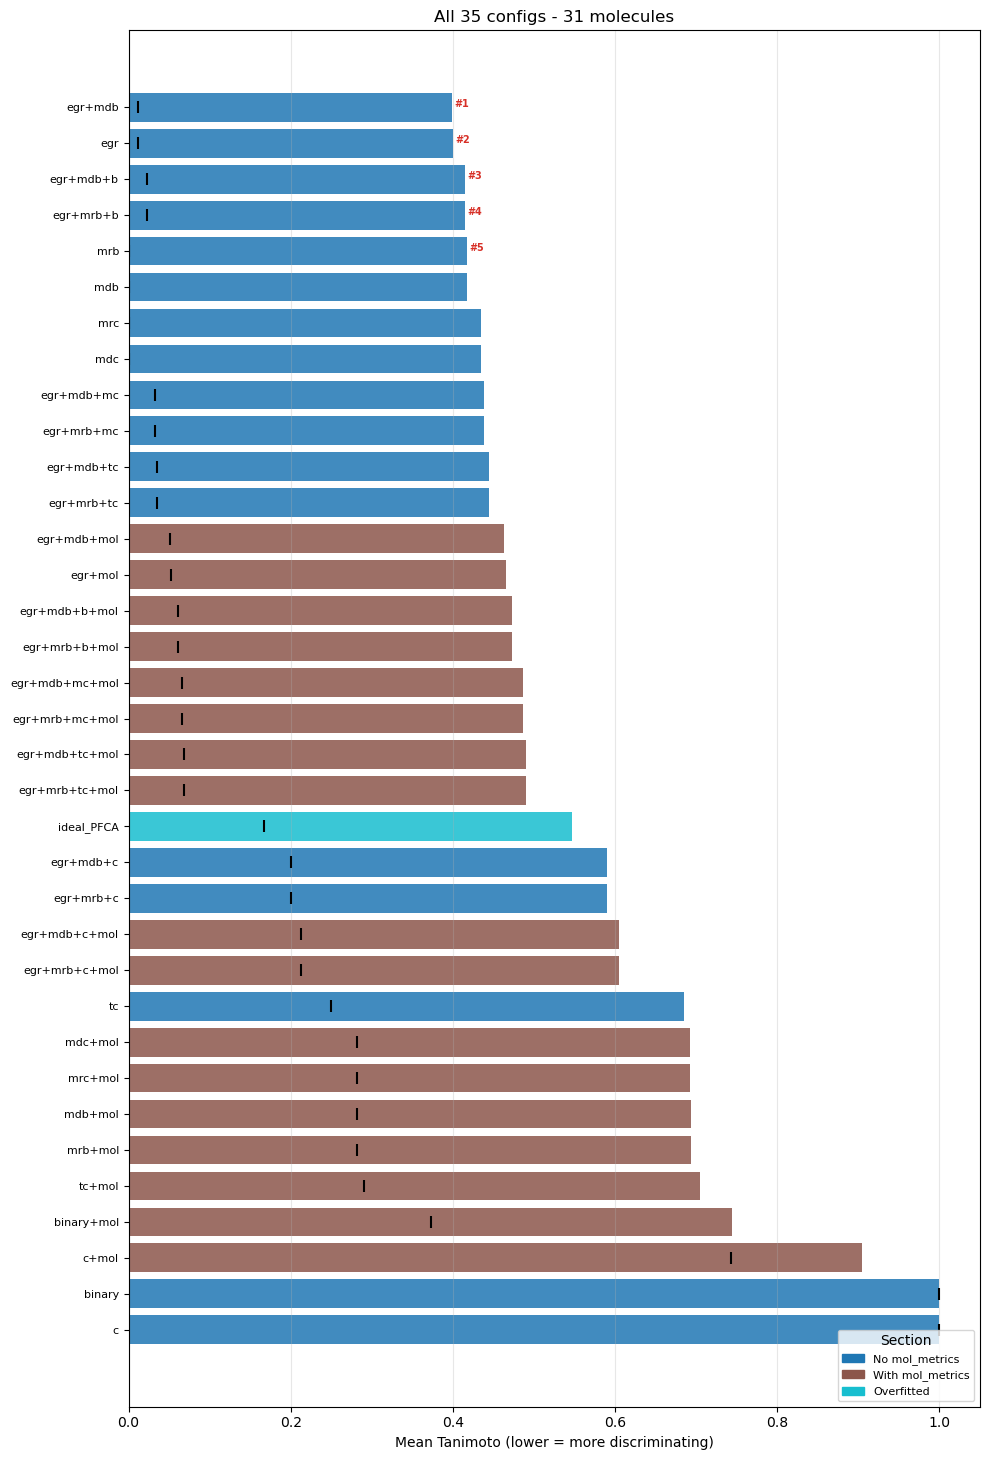


Full ranking:
 rank          label          section  mean_T  min_T  n_cols
    1        egr+mdb   No mol_metrics  0.3988 0.0117     224
    2            egr   No mol_metrics  0.4003 0.0119     112
    3      egr+mdb+b   No mol_metrics  0.4153 0.0230     336
    4      egr+mrb+b   No mol_metrics  0.4153 0.0230     336
    5            mrb   No mol_metrics  0.4176 0.0000     112
    6            mdb   No mol_metrics  0.4176 0.0000     112
    7            mrc   No mol_metrics  0.4351 0.0000     112
    8            mdc   No mol_metrics  0.4351 0.0000     112
    9     egr+mdb+mc   No mol_metrics  0.4379 0.0320     336
   10     egr+mrb+mc   No mol_metrics  0.4379 0.0320     336
   11     egr+mdb+tc   No mol_metrics  0.4443 0.0356     336
   12     egr+mrb+tc   No mol_metrics  0.4443 0.0356     336
   13    egr+mdb+mol With mol_metrics  0.4629 0.0509     228
   14        egr+mol With mol_metrics  0.4649 0.0519     116
   15  egr+mdb+b+mol With mol_metrics  0.4732 0.0605     340
   16  eg

In [6]:
_CMAP = LinearSegmentedColormap.from_list('T', ['#f7fbff','#c6dbef','#6baed6','#2171b5','#08306b'])

def sec_colours(sections):
    uniq = list(dict.fromkeys(sections))
    cm = plt.cm.tab10
    return {s: cm(i/(max(len(uniq)-1,1))) for i,s in enumerate(uniq)}

srt   = sorted(ALL_RESULTS, key=lambda d: d['mean_t'])
labs  = [d['label']   for d in srt]
means = [d['mean_t']  for d in srt]
mins  = [d['min_t']   for d in srt]
secs  = [d['section'] for d in srt]
sc    = sec_colours(secs)
cols  = [sc[s] for s in secs]

n = len(labs)
fig, ax = plt.subplots(figsize=(10, max(5, n*0.42)))
y = np.arange(n)
ax.barh(y, means, color=cols, alpha=0.85)
ax.scatter(mins, y, marker='|', s=70, color='k', zorder=3)
ax.set_yticks(y); ax.set_yticklabels(labs, fontsize=8)
ax.set_xlabel('Mean Tanimoto (lower = more discriminating)')
ax.set_title(f'All {len(ALL_RESULTS)} configs - {len(MOL_DF)} molecules')
ax.legend(handles=[mpatches.Patch(color=c,label=s) for s,c in sc.items()],
          title='Section', loc='lower right', fontsize=8)
for k in range(min(5,n)):
    ax.annotate(f'#{k+1}', xy=(means[k],k), xytext=(means[k]+0.003,k),
                fontsize=7, color='#d73027', fontweight='bold')
ax.grid(axis='x', alpha=0.3); ax.invert_yaxis()
plt.tight_layout()
_SAVED_FIGS['ranking'] = fig
plt.show()

print('\nFull ranking:')
print(pd.DataFrame([dict(rank=i+1, label=d['label'], section=d['section'],
                         mean_T=round(d['mean_t'],4), min_T=round(d['min_t'],4),
                         n_cols=d['n_cols'])
                    for i,d in enumerate(srt)]).to_string(index=False))

## 5. Chain-length sensitivity
Mean Tanimoto between adjacent homologues Cn vs Cn+1 (linear PFCA series).
Lower = fingerprint better distinguishes consecutive chain lengths.

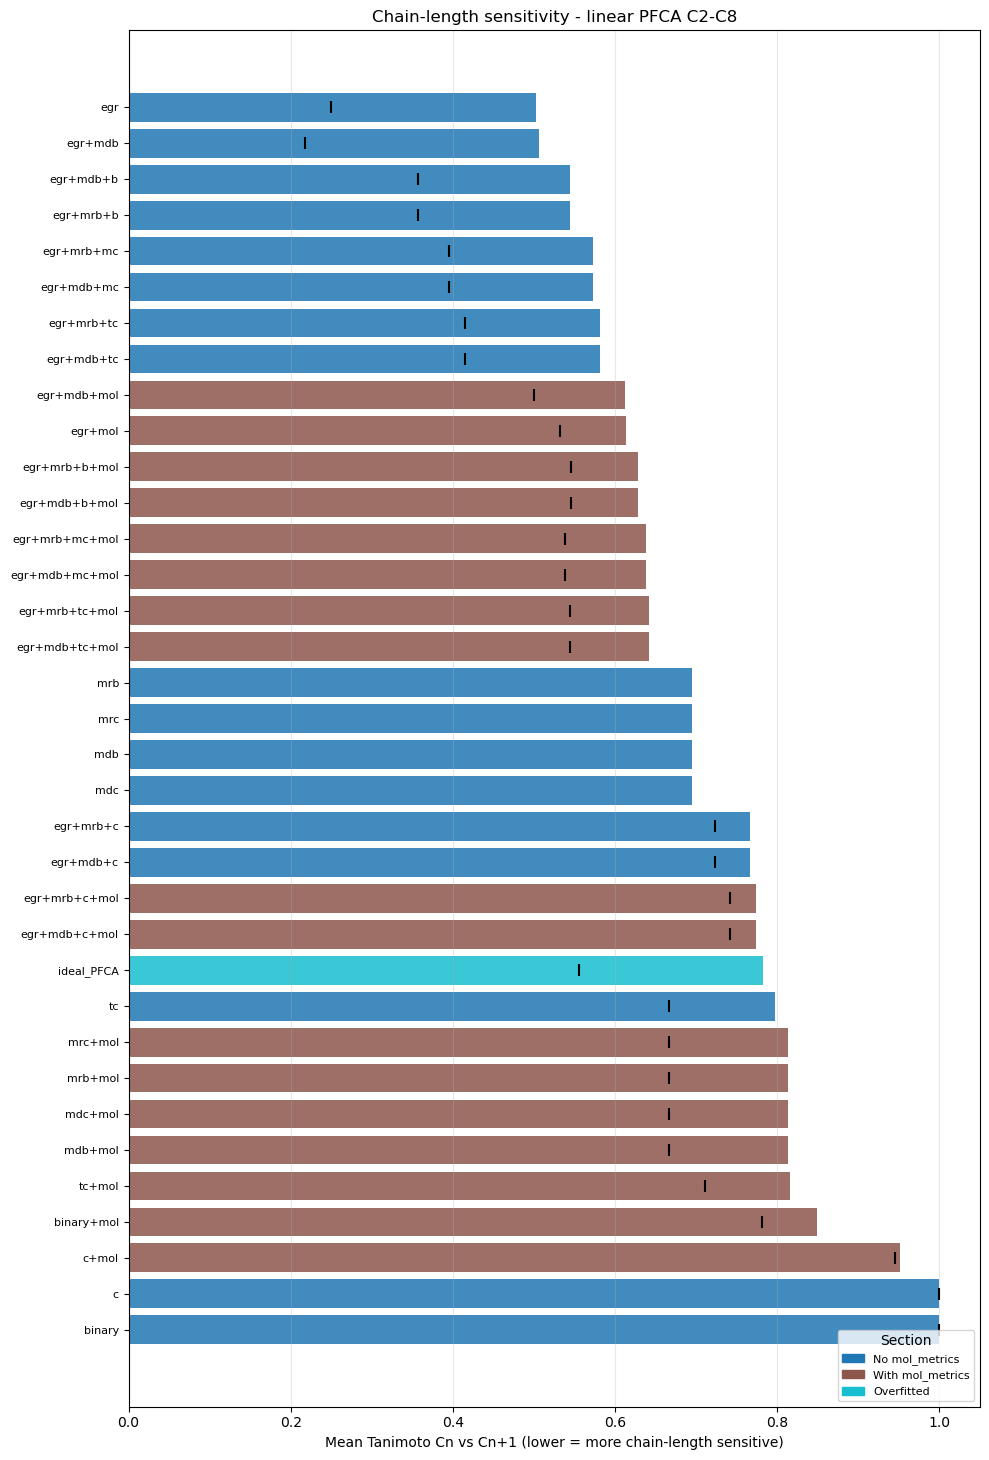

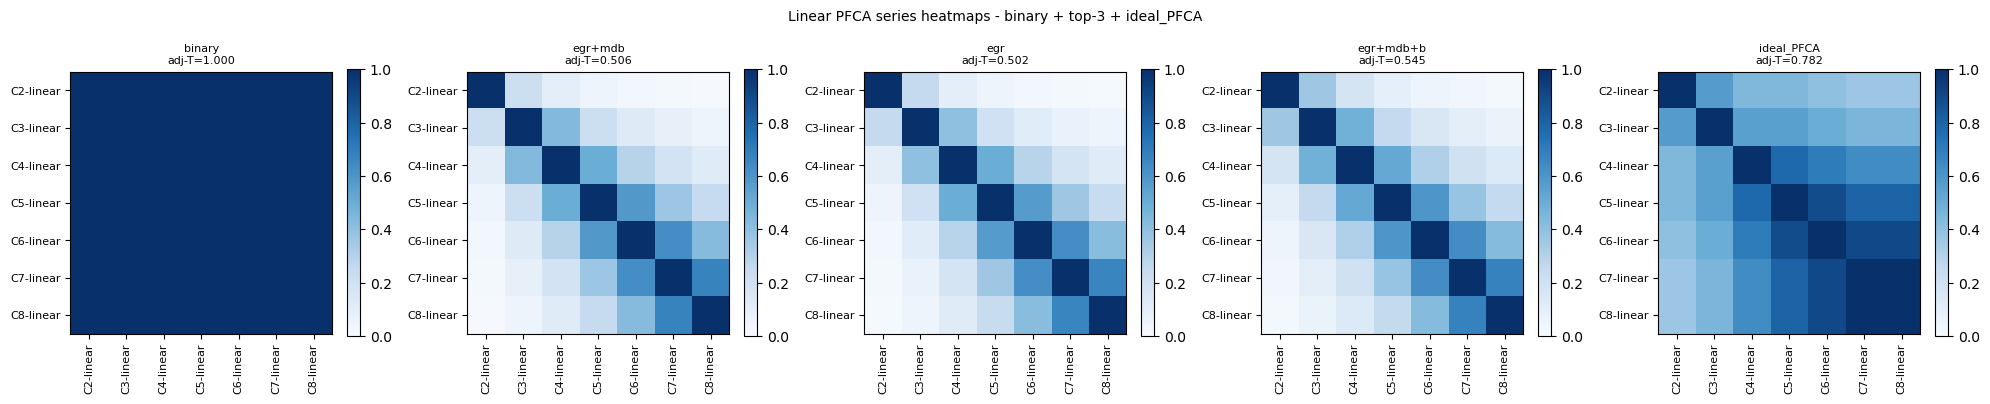

In [7]:
linear_idx = [
    MOL_DF.index[MOL_DF['label'] == f'C{n}-linear'][0] for n in range(2,9)
]
linear_labels = [MOL_DF.loc[i,'label'] for i in linear_idx]

chain_rows = []
for d in ALL_RESULTS:
    S = d['sim']
    adj_ts = [S[linear_idx[k], linear_idx[k+1]] for k in range(len(linear_idx)-1)]
    chain_rows.append(dict(label=d['label'], section=d['section'],
                           adj_mean_T=np.mean(adj_ts), adj_min_T=np.min(adj_ts)))
chain_df = pd.DataFrame(chain_rows).sort_values('adj_mean_T')

n=len(chain_df); fig,ax=plt.subplots(figsize=(10,max(5,n*0.42)))
y=np.arange(n)
sc2=sec_colours(list(chain_df['section']))
cols2=[sc2[s] for s in chain_df['section']]
ax.barh(y,chain_df['adj_mean_T'],color=cols2,alpha=0.85)
ax.scatter(chain_df['adj_min_T'],y,marker='|',s=70,color='k',zorder=3)
ax.set_yticks(y); ax.set_yticklabels(chain_df['label'],fontsize=8)
ax.set_xlabel('Mean Tanimoto Cn vs Cn+1 (lower = more chain-length sensitive)')
ax.set_title('Chain-length sensitivity - linear PFCA C2-C8')
ax.legend(handles=[mpatches.Patch(color=c,label=s) for s,c in sc2.items()],
          title='Section',loc='lower right',fontsize=8)
ax.grid(axis='x',alpha=0.3); ax.invert_yaxis(); plt.tight_layout()
_SAVED_FIGS['chain_sensitivity'] = fig
plt.show()

# show_data: top-3 PFASGroups configs + ideal_PFCA upper bound
top3_lbl  = [d['label'] for d in srt if d['section'] != 'Overfitted'][:3]
show_lbl  = list(dict.fromkeys(['binary'] + top3_lbl + ['ideal_PFCA']))
show_data = sorted([d for d in ALL_RESULTS if d['label'] in show_lbl],
                   key=lambda d: show_lbl.index(d['label']))

nc=len(show_data); fig,axes=plt.subplots(1,nc,figsize=(4*nc,4))
axes=[axes] if nc==1 else list(axes)
for ax,d in zip(axes,show_data):
    sub=d['sim'][np.ix_(linear_idx,linear_idx)]
    im=ax.imshow(sub,cmap=_CMAP,vmin=0,vmax=1)
    ax.set_xticks(range(len(linear_labels)))
    ax.set_xticklabels(linear_labels,rotation=90,fontsize=8)
    ax.set_yticks(range(len(linear_labels)))
    ax.set_yticklabels(linear_labels,fontsize=8)
    cadj = chain_df.set_index('label').loc[d['label'],'adj_mean_T'] \
           if d['label'] in chain_df['label'].values else float('nan')
    ax.set_title(f'{d["label"]}\nadj-T={cadj:.3f}',fontsize=8)
    plt.colorbar(im,ax=ax,fraction=0.046)
fig.suptitle('Linear PFCA series heatmaps - binary + top-3 + ideal_PFCA',fontsize=10)
plt.tight_layout()
_SAVED_FIGS['chain_heatmap'] = fig
plt.show()

## 6. Branching discrimination
Mean Tanimoto between linear and branched isomers (same C-count, n=5-8).
Lower = fingerprint better distinguishes branching.

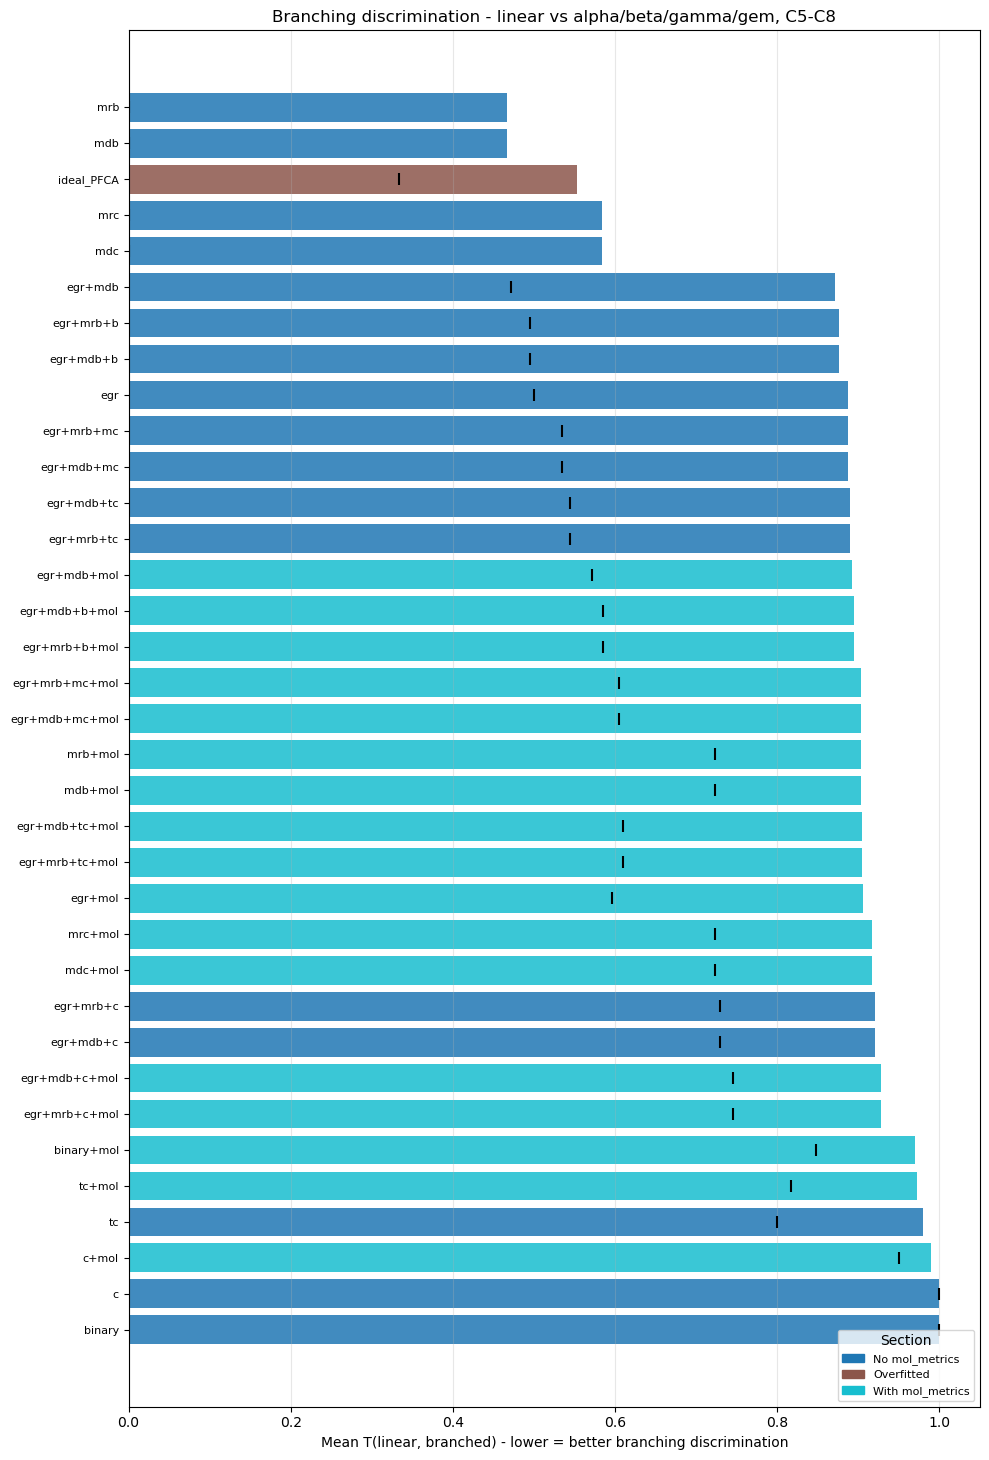

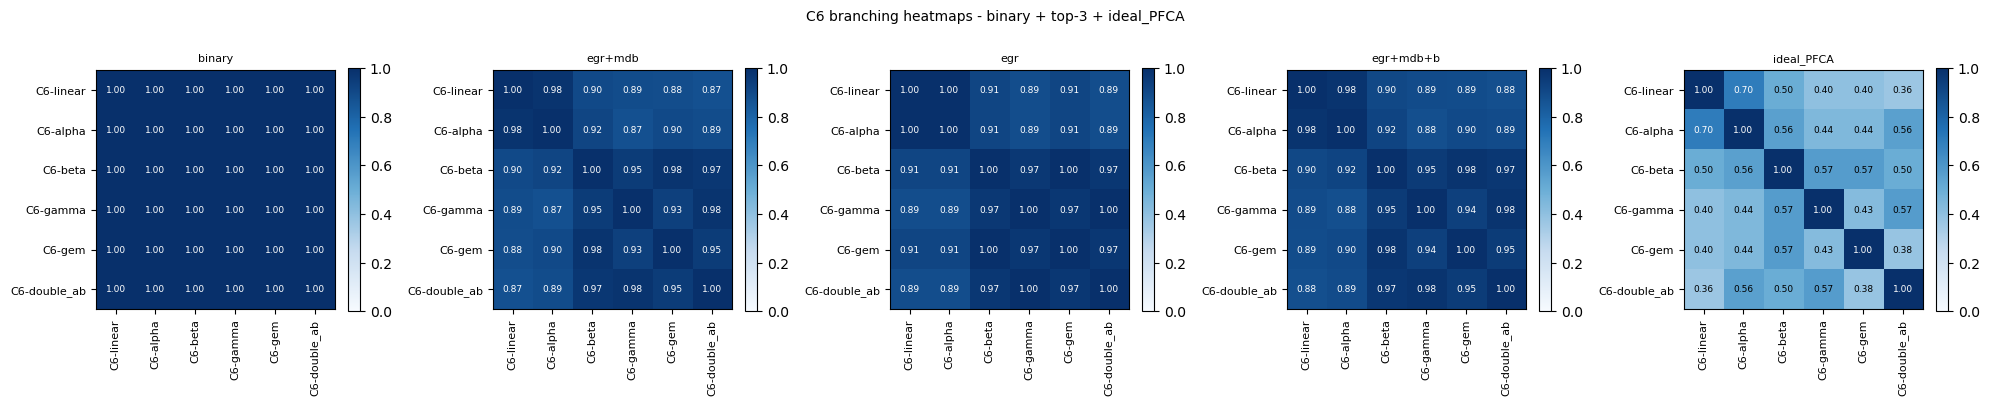


Top branching discriminators:
         label  branch_mean_T  branch_min_T
           mrb       0.466667      0.000000
           mdb       0.466667      0.000000
    ideal_PFCA       0.552828      0.333333
           mrc       0.583333      0.000000
           mdc       0.583333      0.000000
       egr+mdb       0.871477      0.471698
     egr+mrb+b       0.875662      0.495495
     egr+mdb+b       0.875662      0.495495
           egr       0.886667      0.500000
    egr+mrb+mc       0.887453      0.534351
    egr+mdb+mc       0.887453      0.534351
    egr+mdb+tc       0.890059      0.544118
    egr+mrb+tc       0.890059      0.544118
   egr+mdb+mol       0.892584      0.571429
 egr+mdb+b+mol       0.895190      0.585526
 egr+mrb+b+mol       0.895190      0.585526
egr+mrb+mc+mol       0.902631      0.604651
egr+mdb+mc+mol       0.902631      0.604651
       mrb+mol       0.903179      0.723404
       mdb+mol       0.903179      0.723404
egr+mdb+tc+mol       0.904355      0.610169
e

In [8]:
BTYPES = ['linear','alpha','beta','gamma','gem','double_ab']

def get_idx(n, btype):
    rows = MOL_DF.index[(MOL_DF['n_fluoro_c']==n)&(MOL_DF['branching']==btype)]
    return rows[0] if len(rows) else None

branch_rows = []
for d in ALL_RESULTS:
    S = d['sim']; pairs = []
    for n in range(5,9):
        li = get_idx(n,'linear')
        if li is None: continue
        for bt in BTYPES[1:]:
            bi = get_idx(n,bt)
            if bi is not None: pairs.append(S[li,bi])
    branch_rows.append(dict(label=d['label'],section=d['section'],
                            branch_mean_T=np.mean(pairs) if pairs else np.nan,
                            branch_min_T=np.min(pairs) if pairs else np.nan))
branch_df = pd.DataFrame(branch_rows).dropna().sort_values('branch_mean_T')

n=len(branch_df); fig,ax=plt.subplots(figsize=(10,max(5,n*0.42)))
y=np.arange(n)
sc3=sec_colours(list(branch_df['section']))
cols3=[sc3[s] for s in branch_df['section']]
ax.barh(y,branch_df['branch_mean_T'],color=cols3,alpha=0.85)
ax.scatter(branch_df['branch_min_T'],y,marker='|',s=70,color='k',zorder=3)
ax.set_yticks(y); ax.set_yticklabels(branch_df['label'],fontsize=8)
ax.set_xlabel('Mean T(linear, branched) - lower = better branching discrimination')
ax.set_title('Branching discrimination - linear vs alpha/beta/gamma/gem, C5-C8')
ax.legend(handles=[mpatches.Patch(color=c,label=s) for s,c in sc3.items()],
          title='Section',loc='lower right',fontsize=8)
ax.grid(axis='x',alpha=0.3); ax.invert_yaxis(); plt.tight_layout()
_SAVED_FIGS['branch_sensitivity'] = fig
plt.show()

N_DEMO = 6
demo_bt  = [b for b in BTYPES if get_idx(N_DEMO,b) is not None]
demo_idx = [get_idx(N_DEMO,b) for b in demo_bt]
demo_lbl = [f'C{N_DEMO}-{b}' for b in demo_bt]

nc=len(show_data); fig,axes=plt.subplots(1,nc,figsize=(4*nc,4))
axes=[axes] if nc==1 else list(axes)
for ax,d in zip(axes,show_data):
    sub=d['sim'][np.ix_(demo_idx,demo_idx)]
    im=ax.imshow(sub,cmap=_CMAP,vmin=0,vmax=1)
    ax.set_xticks(range(len(demo_lbl)))
    ax.set_xticklabels(demo_lbl,rotation=90,fontsize=8)
    ax.set_yticks(range(len(demo_lbl)))
    ax.set_yticklabels(demo_lbl,fontsize=8)
    ax.set_title(d['label'],fontsize=8)
    plt.colorbar(im,ax=ax,fraction=0.046)
    for i in range(len(demo_lbl)):
        for j in range(len(demo_lbl)):
            ax.text(j,i,f'{sub[i,j]:.2f}',ha='center',va='center',fontsize=6.5,
                    color='white' if sub[i,j]>0.6 else 'black')
fig.suptitle(f'C{N_DEMO} branching heatmaps - binary + top-3 + ideal_PFCA',fontsize=10)
plt.tight_layout()
_SAVED_FIGS['branch_heatmap'] = fig
plt.show()

print('\nTop branching discriminators:')
print(branch_df[['label','branch_mean_T','branch_min_T']].to_string(index=False))

## 7. MDS projections
Left: coloured by chain length. Right: coloured by branching type.
Convex hull contours show group boundaries (as in the HTML report).

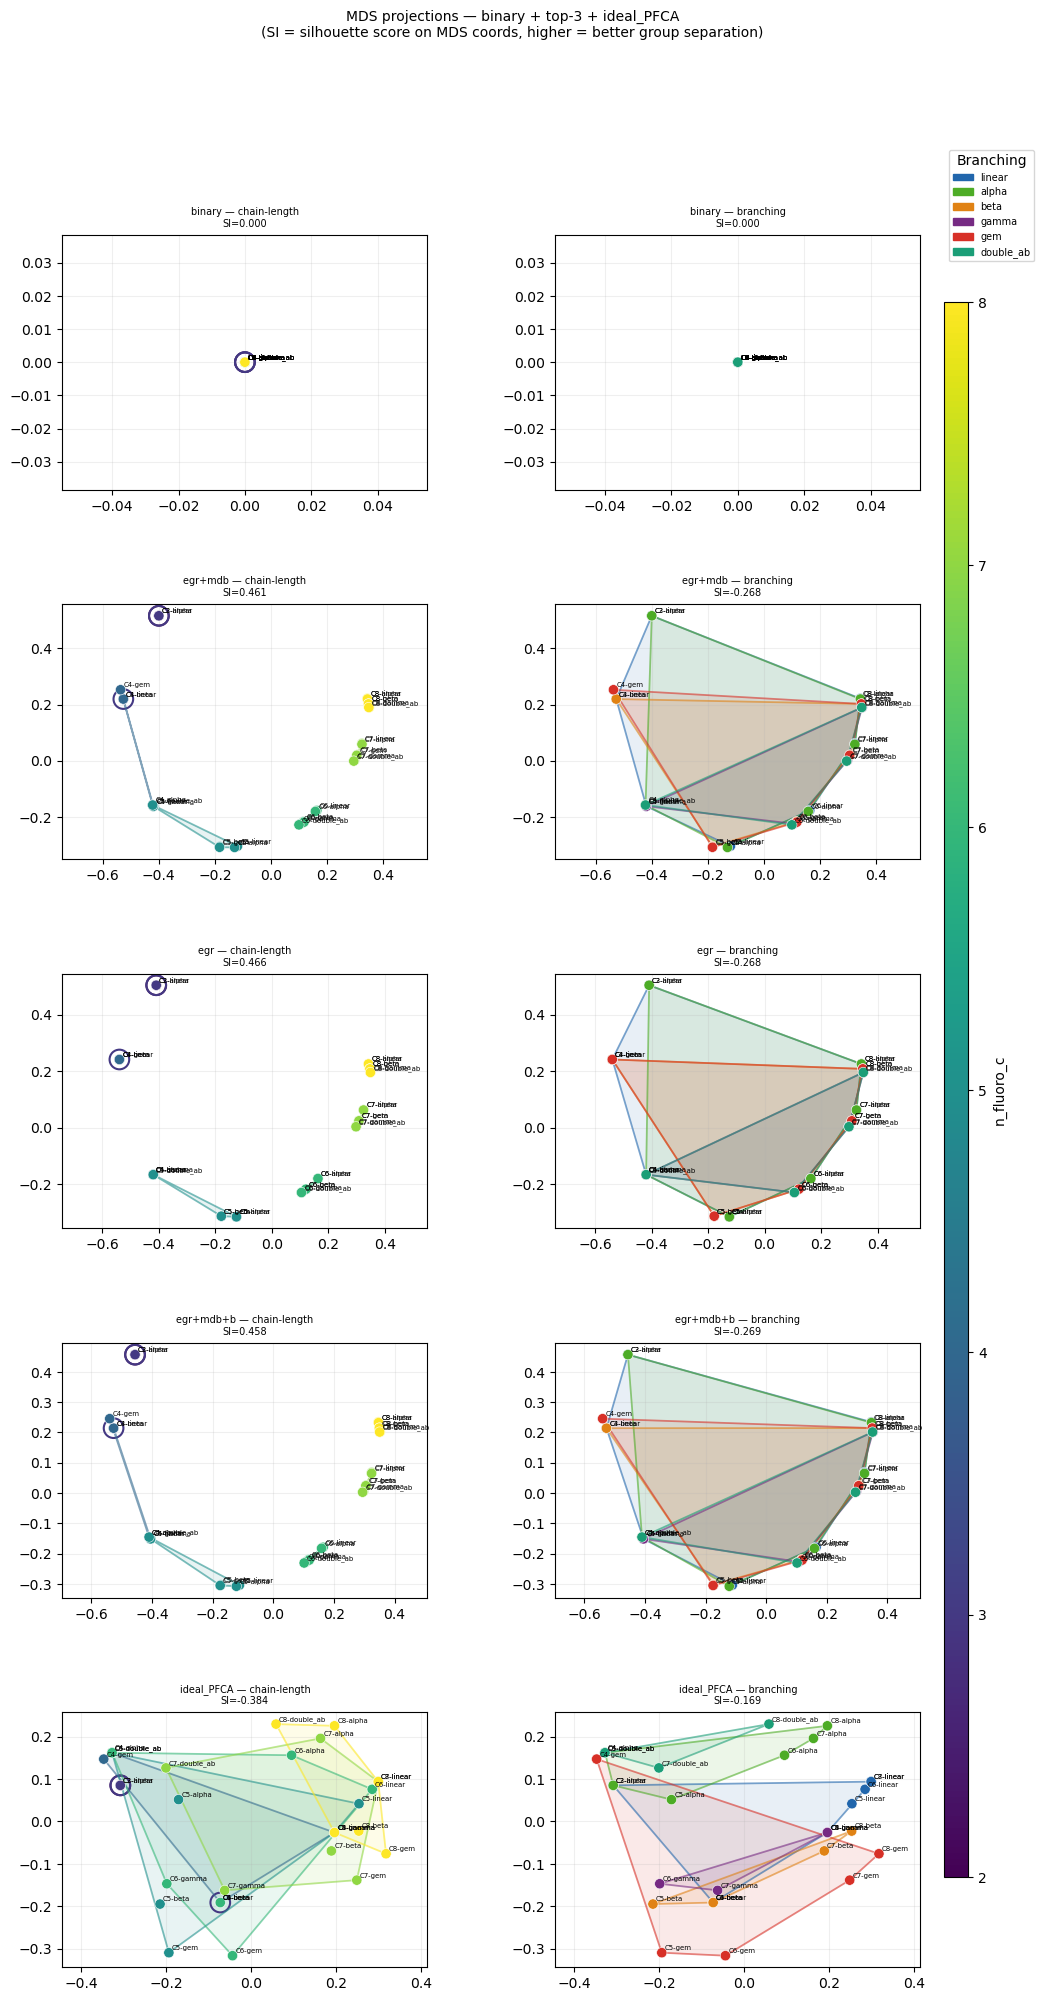

In [9]:
from sklearn.metrics import silhouette_score as _sil_score

def classical_mds(dist, k=2):
    n=dist.shape[0]; D2=dist**2
    H=np.eye(n)-np.ones((n,n))/n; B=-0.5*H@D2@H
    vals,vecs=np.linalg.eigh(B); idx=np.argsort(vals)[::-1]
    vals,vecs=vals[idx],vecs[:,idx]
    return vecs[:,:k]*np.sqrt(np.maximum(vals[:k],0))

def _add_contours(ax, coords, groups, col_lookup):
    """Convex hull contour around each group"""
    group_pts = {}
    for pt, g in zip(coords, groups):
        group_pts.setdefault(g, []).append(pt)
    for g, pts in group_pts.items():
        pts = np.array(pts)
        c = col_lookup[g] if isinstance(col_lookup, dict) else col_lookup(g)
        if len(pts) < 3:
            ax.scatter(*pts.T, s=200, facecolors='none', edgecolors=c, lw=1.5, zorder=2)
            continue
        try:
            hull = ConvexHull(pts)
            verts = np.vstack([pts[hull.vertices], pts[hull.vertices[0]]])
            ax.fill(verts[:,0], verts[:,1], alpha=0.10, color=c, zorder=1)
            ax.plot(verts[:,0], verts[:,1], '-', color=c, lw=1.3, alpha=0.55, zorder=2)
        except Exception:
            pass

CHAIN_CMAP = plt.cm.viridis
BRANCH_COL = {'linear':'#2166ac','alpha':'#4dac26','beta':'#e08214',
              'gamma':'#762a83','gem':'#d73027','double_ab':'#1b9e77'}
cmin, cmax = min(chain_list), max(chain_list)

def chain_col(c):
    return CHAIN_CMAP((c - cmin) / (cmax - cmin + 1e-9))

chain_colours  = [chain_col(c) for c in chain_list]
branch_colours = [BRANCH_COL.get(b,'#888') for b in branching_list]

nc = len(show_data)
fig, axes = plt.subplots(nc, 2, figsize=(12, 4.5*nc))
if nc == 1: axes = axes[np.newaxis, :]

for row, d in enumerate(show_data):
    dist = np.clip(1-d['sim'], 0, None); np.fill_diagonal(dist, 0)
    try:
        coords = classical_mds(dist)
    except Exception:
        for k in range(2): axes[row, k].axis('off')
        continue
    for col, (clrs, groups, clut, title_suf) in enumerate([
        (chain_colours,  chain_list,     chain_col,   'chain-length'),
        (branch_colours, branching_list, BRANCH_COL,  'branching'),
    ]):
        ax = axes[row, col]
        ax.scatter(coords[:,0], coords[:,1], c=clrs, s=55, zorder=3,
                   edgecolors='white', linewidths=0.4)
        for j, lbl in enumerate(labels_list):
            ax.annotate(lbl, coords[j], xytext=(2,2),
                        textcoords='offset points', fontsize=5, zorder=4)
        _add_contours(ax, coords, groups, clut)
        # Silhouette index on MDS coords
        try:
            _sil = _sil_score(coords, groups)
            _sil_str = f'SI={_sil:.3f}'
        except Exception:
            _sil_str = 'SI=N/A'
        ax.set_title(f'{d["label"]} — {title_suf}\n{_sil_str}', fontsize=7)
        ax.axis('equal'); ax.grid(alpha=0.2)

# Colorbar in its own axes strip (avoids intrusion into subplots)
fig.subplots_adjust(right=0.84, hspace=0.45, wspace=0.35)
sm = plt.cm.ScalarMappable(cmap=CHAIN_CMAP, norm=plt.Normalize(cmin, cmax))
sm.set_array([])
cbar_ax = fig.add_axes([0.86, 0.15, 0.02, 0.7])
fig.colorbar(sm, cax=cbar_ax, label='n_fluoro_c')

fig.legend(handles=[mpatches.Patch(color=c, label=b) for b,c in BRANCH_COL.items()],
           title='Branching', bbox_to_anchor=(0.86, 0.92), loc='upper left',
           fontsize=7, ncol=1)
fig.suptitle('MDS projections — binary + top-3 + ideal_PFCA\n(SI = silhouette score on MDS coords, higher = better group separation)', fontsize=10)
_SAVED_FIGS['mds'] = fig
plt.show()


## 8. Per-metric impact vs. binary baseline
Delta mean_T = binary_mean_T minus config_mean_T. Positive = improvement.
Three panels: overall, chain-length, branching.

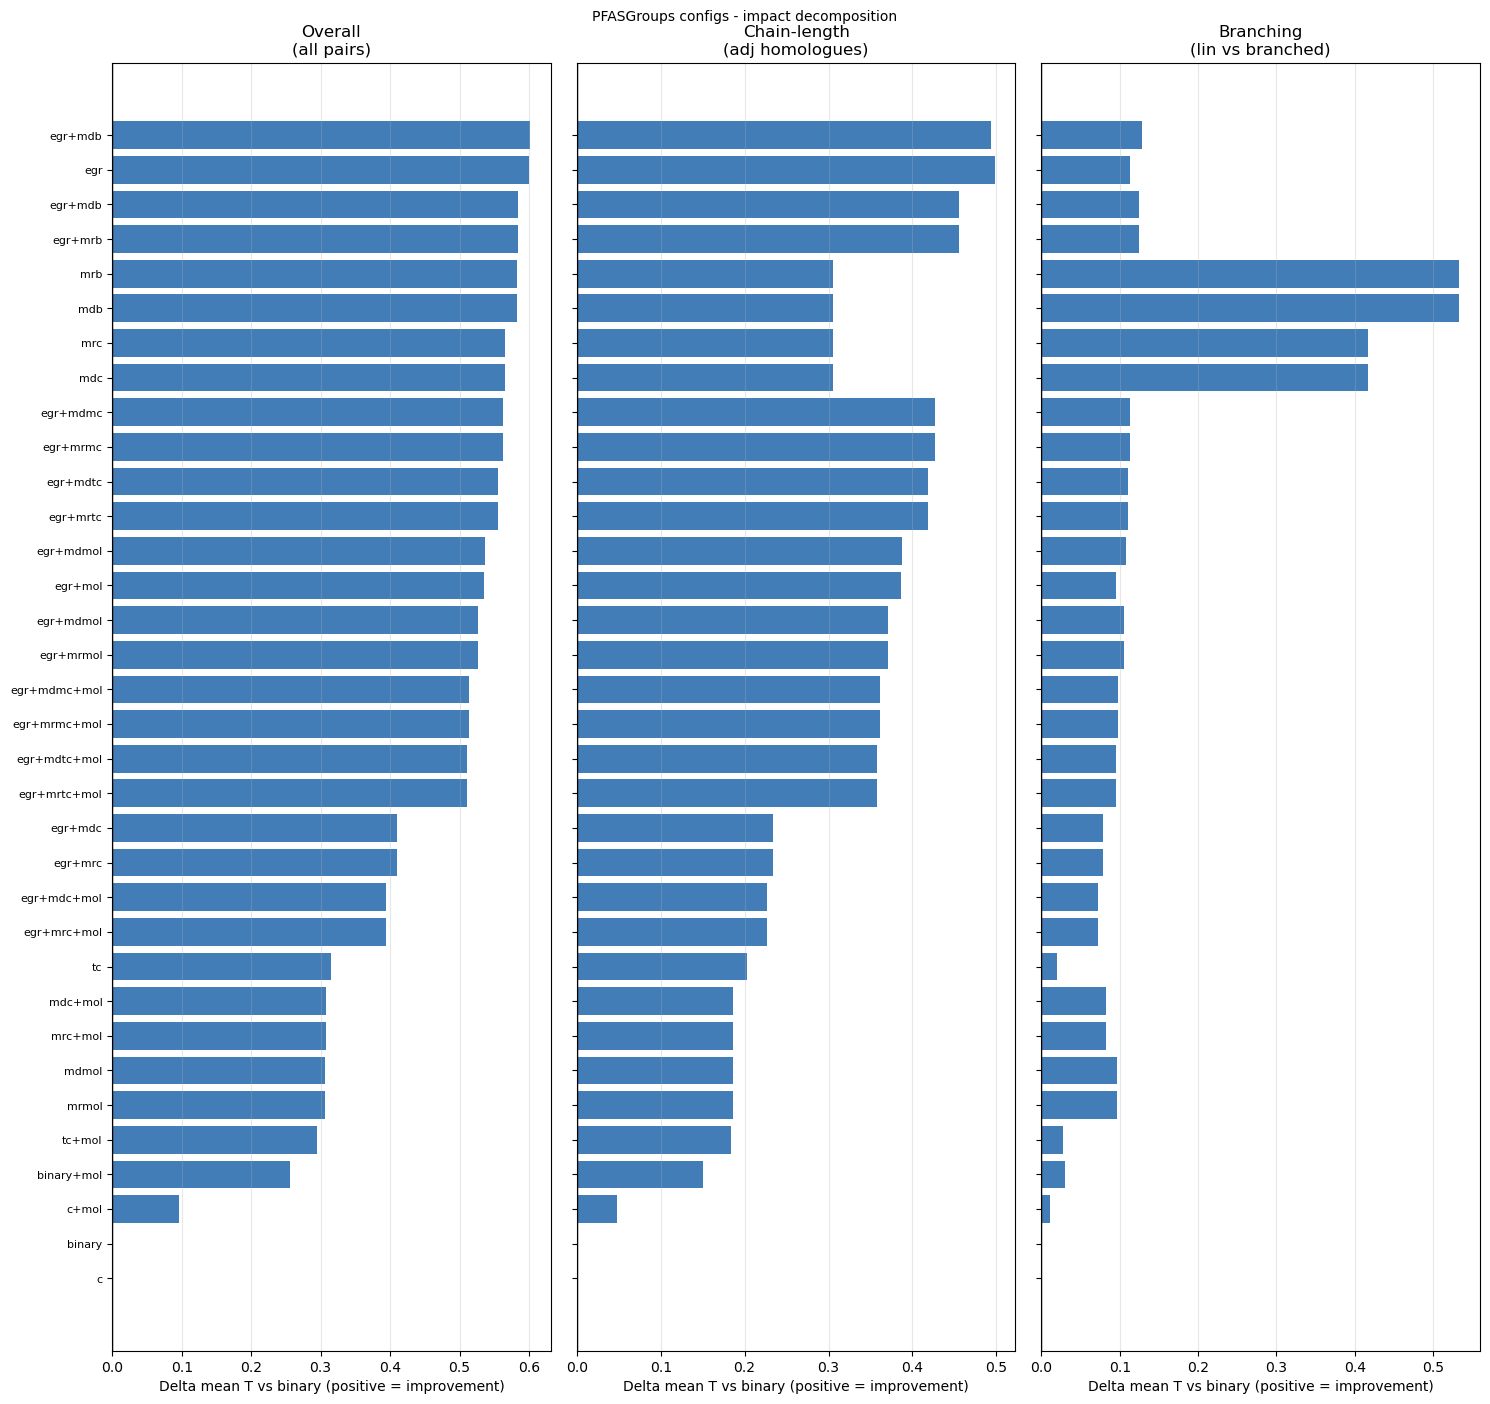

In [10]:
def vec(df, lbl, col):
    row=df[df['label']==lbl]; return float(row[col].iloc[0]) if len(row) else float('nan')

binary_d = next(d for d in ALL_RESULTS if d['label']=='binary')
B_mean   = binary_d['mean_t']
B_chain  = vec(chain_df,  'binary','adj_mean_T')
B_branch = vec(branch_df, 'binary','branch_mean_T') if 'binary' in branch_df['label'].values else float('nan')

def plot_impact(rows, title, fig_key=None):
    labs_ = [d['label'].replace('b+mol:','').replace('b+','') for d in rows]
    do = [B_mean   - d['mean_t']                               for d in rows]
    dc = [B_chain  - vec(chain_df, d['label'],'adj_mean_T')    for d in rows]
    db = [B_branch - vec(branch_df,d['label'],'branch_mean_T') for d in rows]
    fig,axes=plt.subplots(1,3,figsize=(15,max(4,len(rows)*0.42)),sharey=True)
    for ax,deltas,sub in zip(axes,[do,dc,db],
            ['Overall\n(all pairs)','Chain-length\n(adj homologues)',
             'Branching\n(lin vs branched)']):
        y_=np.arange(len(labs_))
        clrs=['#2166ac' if v>0 else '#d73027' for v in deltas]
        ax.barh(y_,deltas,color=clrs,alpha=0.85)
        ax.set_yticks(y_); ax.set_yticklabels(labs_,fontsize=8)
        ax.axvline(0,color='k',lw=1)
        ax.set_xlabel('Delta mean T vs binary (positive = improvement)')
        ax.set_title(sub); ax.grid(axis='x',alpha=0.3); ax.invert_yaxis()
    fig.suptitle(title,fontsize=10); plt.tight_layout()
    if fig_key: _SAVED_FIGS[fig_key] = fig
    plt.show()

non_handcraft = [d for d in srt if d['section'] != 'Overfitted']
plot_impact(non_handcraft, 'PFASGroups configs - impact decomposition', fig_key='impact')

## 9. Tanimoto heatmaps (binary + top configs)

Rows/columns ordered by hierarchical clustering.

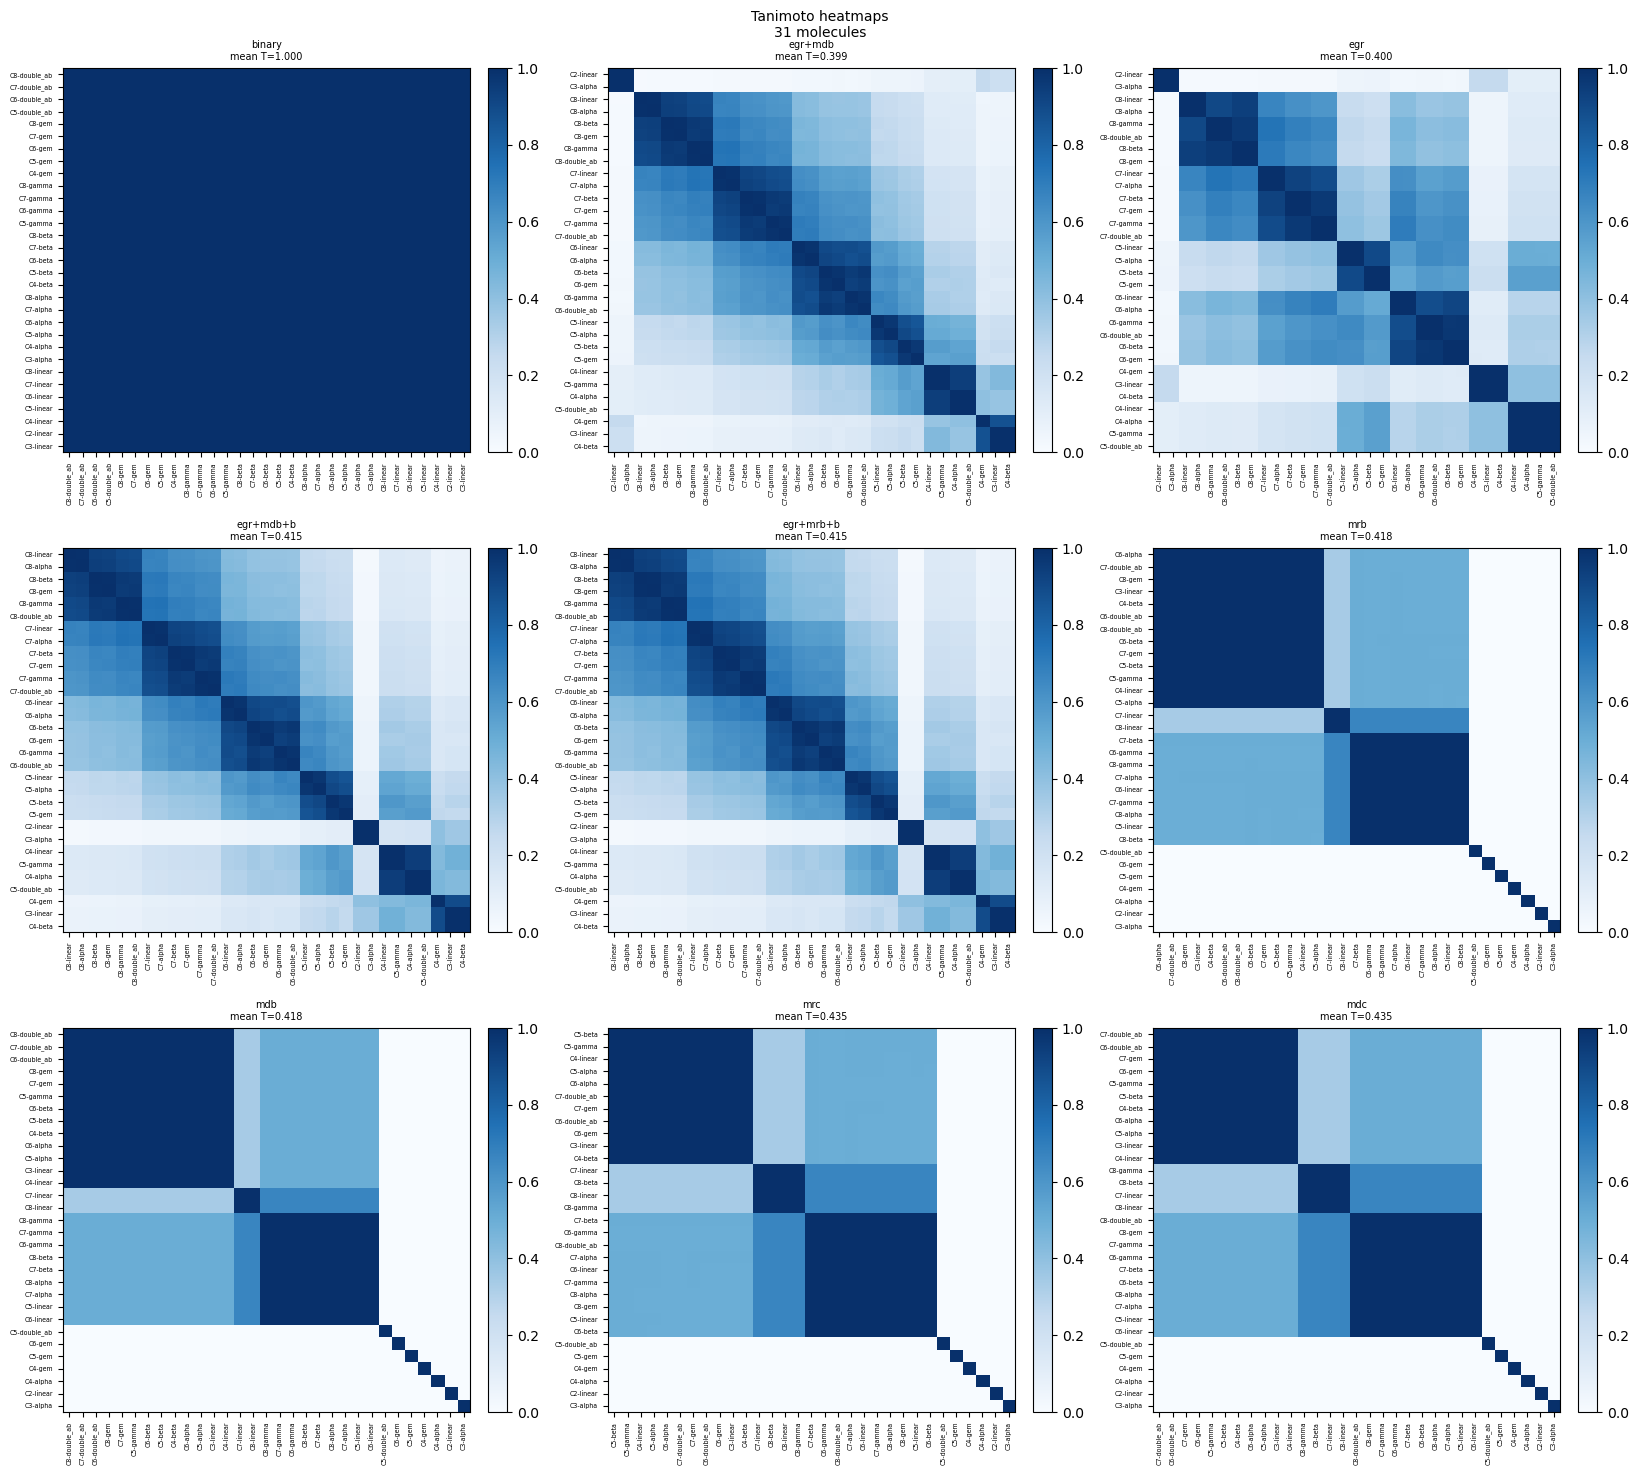

In [11]:
def cluster_order(sim):
    dist=np.clip(1-sim,0,None); np.fill_diagonal(dist,0)
    cond=squareform(dist,checks=False); cond=np.clip(cond,0,None)
    try:    return leaves_list(linkage(cond,method='average'))
    except: return np.arange(len(sim))

# binary + top sorted (ideal_PFCA included wherever it ranks)
show_heat = [next(r for r in ALL_RESULTS if r['label']=='binary')] + srt[:min(8,len(srt))]
show_heat = list({d['label']:d for d in show_heat}.values())  # deduplicate
ncols=3; nrows=int(np.ceil(len(show_heat)/ncols))
fig,axes=plt.subplots(nrows,ncols,figsize=(5.5*ncols,5*nrows))
axes_flat=np.array(axes).flatten()
for i,d in enumerate(show_heat):
    ax=axes_flat[i]
    order=cluster_order(d['sim'])
    s=d['sim'][np.ix_(order,order)]
    lbl=[labels_list[k] for k in order]
    im=ax.imshow(s,cmap=_CMAP,vmin=0,vmax=1,aspect='auto')
    ax.set_xticks(range(len(lbl))); ax.set_xticklabels(lbl,rotation=90,fontsize=4.5)
    ax.set_yticks(range(len(lbl))); ax.set_yticklabels(lbl,fontsize=4.5)
    ax.set_title(f'{d["label"]}\nmean T={d["mean_t"]:.3f}',fontsize=7)
    plt.colorbar(im,ax=ax,fraction=0.046,pad=0.04)
for ax in axes_flat[len(show_heat):]:
    ax.axis('off')
fig.suptitle(f'Tanimoto heatmaps\n{len(MOL_DF)} molecules',fontsize=10)
plt.tight_layout()
_SAVED_FIGS['heatmaps'] = fig
plt.show()

## 10. Separation quality scores — synthetic PFCA grid

For each fingerprint configuration (including `ideal_PFCA`), we compute the **silhouette score**
— a standard cluster-quality index in ∈ [−1, 1] (higher = tighter intra-group cohesion,
better inter-group separation) — across four structural groupings:

| Grouping | What it captures |
|---|---|
| **chain-length** | n_fluoro_c ∈ {2…8} |
| **branching** | linear / α / β / γ / gem / double_αβ |
| **component_count** | number of distinct fluorinated chains (1 for linear, 2+ for branched) |
| **func_group** | SMARTS-based functional-group composition vector (CF₃, CF₂, α/β/γ/gem motifs) |

Silhouette is computed both in **raw fingerprint space** (using Tanimoto distance)
and on **2-D MDS coordinates** for a consistent visual comparison.
The `Richard2023` real-world fingerprint is also included on
the molecules that overlap with the synthetic grid.


Computing silhouette scores for all configs ...
Done.


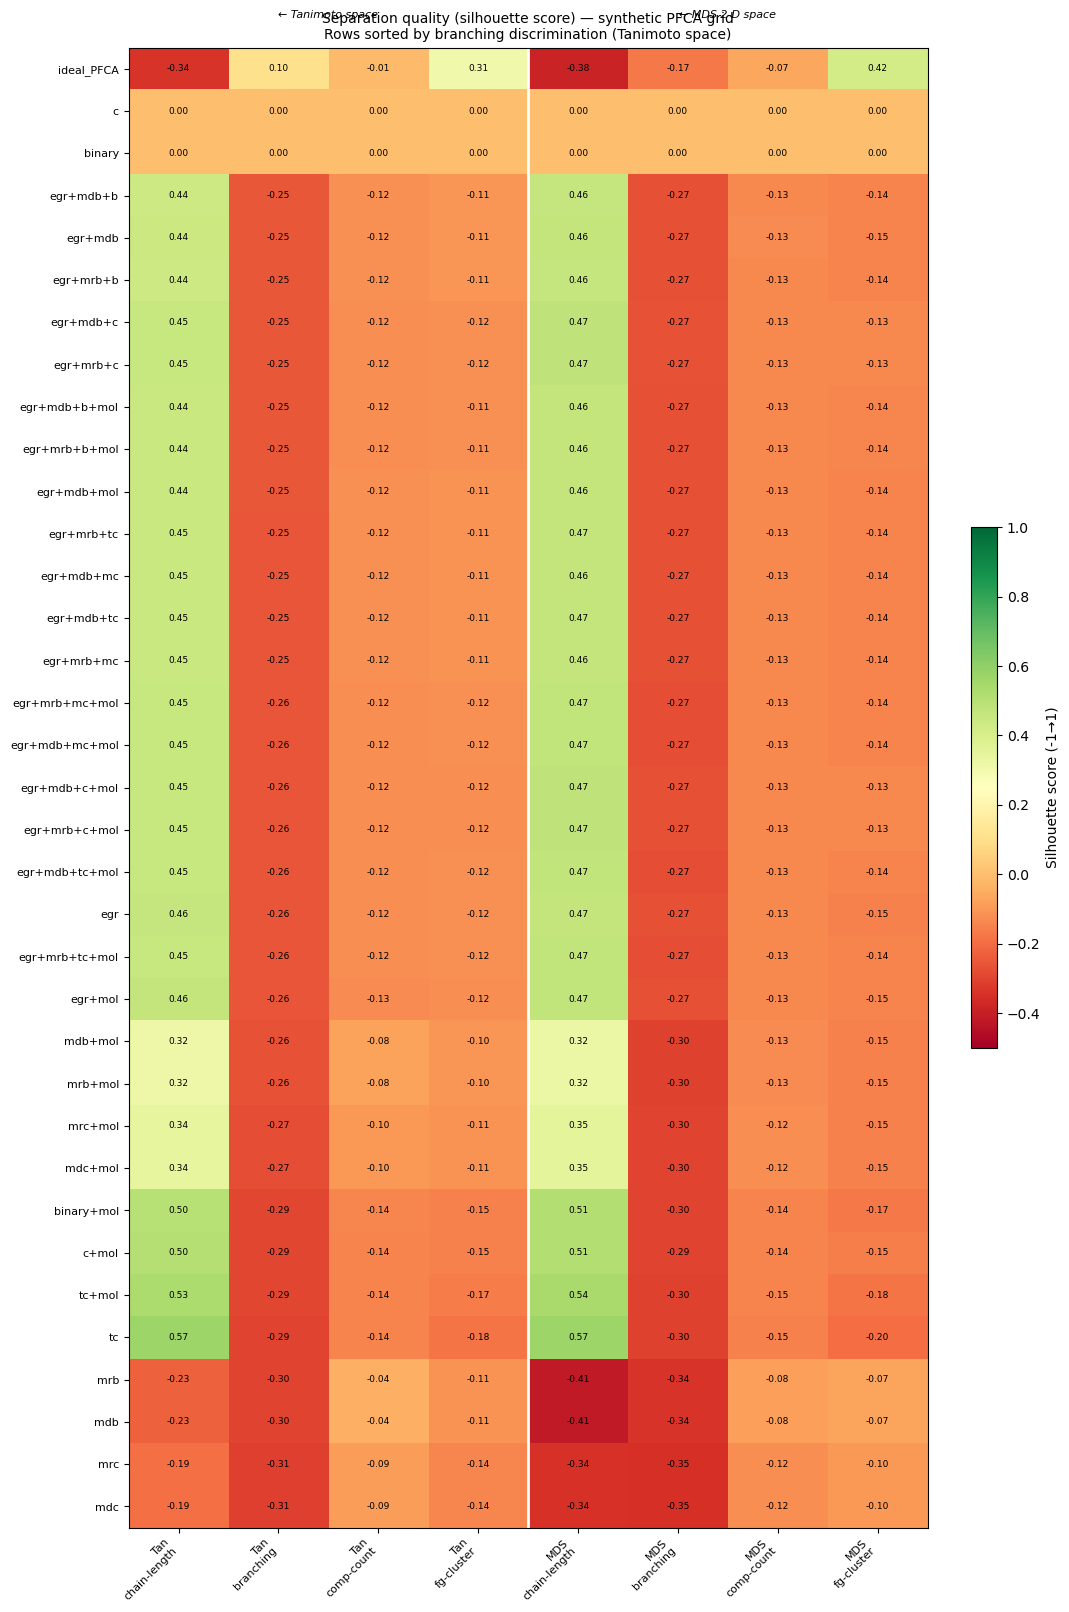


Full table:


,label,section,tan_chain-length,tan_branching,tan_comp-count,tan_fg-cluster,mds_chain-length,mds_branching,mds_comp-count,mds_fg-cluster
34,ideal_PFCA,Overfitted,-0.337,0.104,-0.011,0.306,-0.384,-0.169,-0.066,0.418
2,c,No mol_metrics,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
0,binary,No mol_metrics,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
24,egr+mdb+b,No mol_metrics,0.437,-0.251,-0.116,-0.107,0.458,-0.269,-0.131,-0.145
10,egr+mdb,No mol_metrics,0.440,-0.251,-0.115,-0.106,0.461,-0.268,-0.130,-0.148
32,egr+mrb+b,No mol_metrics,0.437,-0.251,-0.116,-0.107,0.458,-0.269,-0.131,-0.145
22,egr+mdb+c,No mol_metrics,0.450,-0.252,-0.122,-0.118,0.474,-0.265,-0.132,-0.132
30,egr+mrb+c,No mol_metrics,0.450,-0.252,-0.122,-0.118,0.474,-0.265,-0.132,-0.132
25,egr+mdb+b+mol,With mol_metrics,0.444,-0.253,-0.120,-0.114,0.462,-0.271,-0.133,-0.142
33,egr+mrb+b+mol,With mol_metrics,0.444,-0.253,-0.120,-0.114,0.462,-0.271,-0.133,-0.142


In [12]:
from sklearn.metrics import silhouette_score as _sil_score

# ── 1. Derived structural labels ─────────────────────────────────────────────
# Component count: number of distinct fluorinated chains
_comp_count = {
    'linear': 1, 'alpha': 2, 'beta': 2, 'gamma': 2, 'gem': 3, 'double_ab': 3,
}
comp_count_list = [str(_comp_count[b]) for b in branching_list]   # '1','2','3'

# Functional-group fingerprint (SMARTS-based) – used to measure functional similarity
_FG_SMARTS = [
    ('CF3',         'C(F)(F)F'),
    ('CF2',         '[CX4;!$(C(F)(F)F)](F)(F)'),
    ('alpha_CF3',   'OC(=O)C(F)(C(F)(F)F)'),
    ('beta_CF3',    'OC(=O)C(F)(F)C(F)(C(F)(F)F)'),
    ('gamma_CF3',   'OC(=O)C(F)(F)C(F)(F)C(F)(C(F)(F)F)'),
    ('gem_diCF3',   'OC(=O)C(C(F)(F)F)(C(F)(F)F)'),
    ('ab_diCF3',    'OC(=O)C(F)(C(F)(F)F)C(F)(C(F)(F)F)'),
    ('long_CF2',    'C(F)(F)C(F)(F)C(F)(F)C(F)(F)'),
]
from rdkit import Chem as _rdChem
_FG_PATS = [(n, _rdChem.MolFromSmarts(s)) for n, s in _FG_SMARTS]
_FG_NAMES = [n for n, _ in _FG_PATS]

def _fg_matrix(smiles_lst):
    X = np.zeros((len(smiles_lst), len(_FG_PATS)), dtype=float)
    for i, smi in enumerate(smiles_lst):
        mol = _rdChem.MolFromSmiles(smi)
        if mol is None: continue
        for j, (_, pat) in enumerate(_FG_PATS):
            if pat is not None and mol.HasSubstructMatch(pat):
                X[i, j] = float(len(mol.GetSubstructMatches(pat)))
    return X

_fg_mat = _fg_matrix(smiles_list)
# K-means cluster-label for func_group (3 clusters: dominant CF3-branching pattern)
from sklearn.cluster import KMeans
_km = KMeans(n_clusters=4, random_state=0, n_init='auto').fit(_fg_mat)
fg_cluster_list = [str(c) for c in _km.labels_]

# ── 2. Silhouette scores in Tanimoto space (precomputed distance) ─────────────
_GROUPINGS = [
    ('chain-length',    chain_list),
    ('branching',       branching_list),
    ('comp-count',      comp_count_list),
    ('fg-cluster',      fg_cluster_list),
]

def _tansil(sim_mat, group_labels):
    """Silhouette score using 1-Tanimoto distance matrix."""
    labels = list(group_labels)
    if len(set(labels)) < 2:
        return float('nan')
    dist = np.clip(1 - sim_mat, 0, None); np.fill_diagonal(dist, 0)
    try:
        return float(_sil_score(dist, labels, metric='precomputed'))
    except Exception:
        return float('nan')

def _mds_sil(sim_mat, group_labels):
    """Silhouette score in 2-D MDS embedding."""
    labels = list(group_labels)
    if len(set(labels)) < 2:
        return float('nan')
    dist = np.clip(1 - sim_mat, 0, None); np.fill_diagonal(dist, 0)
    try:
        coords = classical_mds(dist)
        return float(_sil_score(coords, labels))
    except Exception:
        return float('nan')

print('Computing silhouette scores for all configs ...')
_sep_rows = []
for d in ALL_RESULTS:
    row = dict(label=d['label'], section=d['section'])
    for gname, glbls in _GROUPINGS:
        row[f'tan_{gname}']  = round(_tansil(d['sim'], glbls), 3)
        row[f'mds_{gname}']  = round(_mds_sil(d['sim'], glbls), 3)
    _sep_rows.append(row)

sep_df = pd.DataFrame(_sep_rows).sort_values('tan_branching', ascending=False)
print('Done.')

# ── 3. Heat-map visualisation ─────────────────────────────────────────────────
_score_cols = [f'tan_{g}' for g,_ in _GROUPINGS] + [f'mds_{g}' for g,_ in _GROUPINGS]
_plot_df = sep_df.set_index('label')[_score_cols]

fig, ax = plt.subplots(figsize=(len(_score_cols)*1.1 + 2, len(sep_df)*0.42 + 1.5))
_vals = _plot_df.values.astype(float)
im = ax.imshow(_vals, cmap='RdYlGn', vmin=-0.5, vmax=1.0, aspect='auto')
ax.set_xticks(range(len(_score_cols)))
ax.set_xticklabels(
    [c.replace('tan_','Tan\n').replace('mds_','MDS\n') for c in _score_cols],
    fontsize=8, rotation=45, ha='right'
)
ax.set_yticks(range(len(sep_df)))
ax.set_yticklabels(sep_df['label'], fontsize=8)
for i in range(_vals.shape[0]):
    for j in range(_vals.shape[1]):
        v = _vals[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6.5,
                    color='black' if abs(v) < 0.6 else 'white')
plt.colorbar(im, ax=ax, fraction=0.03, label='Silhouette score (-1→1)')
# Vertical separator between Tanimoto and MDS halves
ax.axvline(len(_GROUPINGS) - 0.5, color='white', lw=2)
ax.text(len(_GROUPINGS)/2 - 0.5,  -1.2, '← Tanimoto space',  ha='center', fontsize=8, fontstyle='italic')
ax.text(len(_GROUPINGS)*1.5 - 0.5,-1.2, '← MDS 2-D space',   ha='center', fontsize=8, fontstyle='italic')
ax.set_title(
    'Separation quality (silhouette score) — synthetic PFCA grid\n'
    'Rows sorted by branching discrimination (Tanimoto space)',
    fontsize=10
)
plt.tight_layout()
_SAVED_FIGS['sep_quality'] = fig
plt.show()

print('\nFull table:')
display(sep_df[['label','section'] + _score_cols]
    .style.background_gradient(subset=_score_cols, cmap='RdYlGn', vmin=-0.5, vmax=1.0)
    .format({c: '{:.3f}' for c in _score_cols}))


## 10. Summary

In [13]:
summary = pd.DataFrame([dict(
    rank=i+1, label=d['label'], section=d['section'],
    mean_T=round(d['mean_t'],4), min_T=round(d['min_t'],4), n_cols=d['n_cols'],
    chain_adj_T=round(vec(chain_df, d['label'],'adj_mean_T'),4),
    branch_T   =round(vec(branch_df,d['label'],'branch_mean_T'),4),
) for i,d in enumerate(srt)])

display(summary.style
    .background_gradient(subset=['mean_T'],      cmap='RdYlGn_r', vmin=0, vmax=1)
    .background_gradient(subset=['chain_adj_T'], cmap='RdYlGn_r', vmin=0, vmax=1)
    .background_gradient(subset=['branch_T'],    cmap='RdYlGn_r', vmin=0, vmax=1)
    .format(precision=4)
)

out_csv = NOTEBOOK_DIR / 'results' / 'tanimoto' / 'structure_analysis_summary.csv'
out_csv.parent.mkdir(parents=True, exist_ok=True)
summary.to_csv(out_csv, index=False)
print(f'Saved -> {out_csv}')

best_all    = summary.nsmallest(1,'mean_T').iloc[0]['label']
best_chain  = summary.nsmallest(1,'chain_adj_T').iloc[0]['label']
best_branch = summary.nsmallest(1,'branch_T').iloc[0]['label']
print(f'\nBest overall:   {best_all}')
print(f'Best chain-len: {best_chain}')
print(f'Best branching: {best_branch}')

,rank,label,section,mean_T,min_T,n_cols,chain_adj_T,branch_T
0,1,egr+mdb,No mol_metrics,0.3988,0.0117,224,0.5062,0.8715
1,2,egr,No mol_metrics,0.4003,0.0119,112,0.5022,0.8867
2,3,egr+mdb+b,No mol_metrics,0.4153,0.0230,336,0.5449,0.8757
3,4,egr+mrb+b,No mol_metrics,0.4153,0.0230,336,0.5449,0.8757
4,5,mrb,No mol_metrics,0.4176,0.0000,112,0.6944,0.4667
5,6,mdb,No mol_metrics,0.4176,0.0000,112,0.6944,0.4667
6,7,mrc,No mol_metrics,0.4351,0.0000,112,0.6944,0.5833
7,8,mdc,No mol_metrics,0.4351,0.0000,112,0.6944,0.5833
8,9,egr+mdb+mc,No mol_metrics,0.4379,0.0320,336,0.5726,0.8875
9,10,egr+mrb+mc,No mol_metrics,0.4379,0.0320,336,0.5726,0.8875


Saved -> C:\Users\luc\git\PFASGroups\benchmark\results\tanimoto\structure_analysis_summary.csv

Best overall:   egr+mdb
Best chain-len: egr
Best branching: mrb


## 11. Real-world transferability — Richard et al. 2023 dataset

The synthetic PFCA grid above showed `ideal_PFCA` outperforms PFASGroups on **branching**,
but that is by construction: its patterns were designed for exactly this test set.

Here we test on the full **14 735-molecule** dataset from Richard et al. (2023),
which spans diverse PFAS classes (PFSA, PFPA, sulfonamides, telomers, …).

- **Richard 2023 fingerprint vectors** are loaded from `test_data/Richard2023_SI_TableS2.csv`.
- **SMILES** are looked up from `test_data/Richard2023_SI_TableS5.csv` (DTXSID → SMILES).
  This avoids any network requests and uses the authoritative structures from the same paper.
- Both fingerprints are compared on the same molecules (intersection matched by DTXSID).

In [14]:
_FP_CSV      = NOTEBOOK_DIR / 'test_data' / 'Richard2023_SI_TableS2.csv'
_SMILES_CSV  = NOTEBOOK_DIR / 'test_data' / 'Richard2023_SI_TableS5.csv'

# ── Load Richard 2023 fingerprint matrix (TableS2) ──────────────────────────
_txp_df  = pd.read_csv(_FP_CSV, index_col=0)
_dtxsids = list(_txp_df.index)
print(f'Richard2023 fp matrix : {_txp_df.shape[0]:,} molecules × {_txp_df.shape[1]} bits')

# ── Build DTXSID → SMILES lookup from TableS5 ───────────────────────────────
_s5 = pd.read_csv(_SMILES_CSV, dtype=str)
_s5.columns = [c.strip() for c in _s5.columns]
_dtx_col = next(c for c in _s5.columns if 'DTXSID' in c.upper())
_smi_col = next(
    (c for c in _s5.columns if c.upper() == 'SMILES'),
    next((c for c in _s5.columns if 'SMILES' in c.upper()), None)
)
if _smi_col is None:
    raise ValueError(f'No SMILES column found in {_SMILES_CSV.name}')

_smiles_lookup = {
    dtx: smi
    for dtx, smi in zip(_s5[_dtx_col], _s5[_smi_col])
    if pd.notna(dtx) and pd.notna(smi) and str(smi).strip()
}
print(f'SMILES lookup (TableS5): {len(_smiles_lookup):,} entries')

# ── Match fingerprint matrix rows to SMILES ──────────────────────────────────
_covered = [d for d in _dtxsids if d in _smiles_lookup]
_missing = [d for d in _dtxsids if d not in _smiles_lookup]

# -- try to match missing using PubChem ---

from pubchem import cas_to_smiles
from tqdm import tqdm

_cs, _ = cas_to_smiles(_missing)
_smiles_lookup.update({k:v for k,v in _cs.items() if v})
_covered.extend([d for d in _cs])
_missing = [d for d in _dtxsids if d not in _smiles_lookup]

print(f'Coverage: {len(_covered):,}/{len(_dtxsids):,} '
      f'({100*len(_covered)/max(len(_dtxsids),1):.1f}%)')
if _missing[:5]:
    print(f'First 5 missing DTXSIDs: {_missing[:5]}')


Richard2023 fp matrix : 14,735 molecules × 129 bits
SMILES lookup (TableS5): 14,726 entries
Processing CAS: DTXSID60957127


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.15it/s]


  Failed: CAS not found in PubChem
Processing CAS: DTXSID401015355


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.75it/s]


  Failed: CAS not found in PubChem
Processing CAS: DTXSID40474327


...

  Success: 5 unique molecules found
Processing CAS: DTXSID40880545


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.53it/s]


  Failed: CAS not found in PubChem
Processing CAS: DTXSID501032770


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.69it/s]

  Failed: CAS not found in PubChem
Coverage: 14,735/14,735 (100.0%)
First 5 missing DTXSIDs: ['DTXSID60957127', 'DTXSID401015355', 'DTXSID90149518', 'DTXSID50796805', 'DTXSID40880545']


### 11b. Compute PFASGroups fingerprints and compare against Richard 2023 fingerprint

In [15]:
import pickle, hashlib, time

# Restrict to molecules that have both a fingerprint row AND a SMILES entry
_valid_dtx  = [d for d in _dtxsids if d in _smiles_lookup]
_valid_idx  = [i for i, d in enumerate(_dtxsids) if d in _smiles_lookup]
_valid_smi  = [_smiles_lookup[d] for d in _valid_dtx]
_txp_sub    = _txp_df.iloc[_valid_idx].values.astype(float)

print(f'Working set: {len(_valid_dtx):,} molecules')

# --- PFASGroups fingerprints (best config + binary baseline) ---
_txp_configs = []
i = 0
while i < 10 and srt[i]['label'] != "ideal_PFCA":
    _txp_configs.append((srt[i]['label'], srt[i]['kwargs']))
    i += 1
# deduplicate
_txp_configs = list({l: kw for l, kw in _txp_configs}.items())

print(f"The following configs will be computed:\n" + '\n'.join(f'  {l}' for l, _ in _txp_configs))

# ── Cache helpers ─────────────────────────────────────────────────────────────
_CACHE_DIR = NOTEBOOK_DIR / 'results' / 'cache'
_CACHE_DIR.mkdir(parents=True, exist_ok=True)

def _dtx_hash(dtx_list):
    """Stable hash of the working-set DTXSIDs, used to detect set changes."""
    return hashlib.md5('|'.join(sorted(dtx_list)).encode()).hexdigest()[:12]

_WORKING_HASH = _dtx_hash(_valid_dtx)

def _cache_path(label):
    safe = label.replace('+', 'p').replace(' ', '_')
    return _CACHE_DIR / f'rw_fp_{safe}_{_WORKING_HASH}.npz'

def _save_cache(label, mat, ok_mask):
    np.savez_compressed(_cache_path(label), mat=mat, ok_mask=ok_mask,
                        dtxsids=np.array(_valid_dtx))
    print(f'  [{label}] cached -> {_cache_path(label).name}')

def _load_cache(label):
    p = _cache_path(label)
    if not p.exists():
        return None, None
    data = np.load(p, allow_pickle=True)
    if list(data['dtxsids']) != _valid_dtx:
        print(f'  [{label}] cache DTXSIDs mismatch \u2014 recomputing')
        return None, None
    return data['mat'], data['ok_mask']

# ── Parse all molecules ONCE using PFASFingerprint with match caching ─────
# This runs the PFASGroups algorithm once over all ~14k molecules.
# Subsequent get_fingerprint() calls reuse the cached match results instantly.

_any_needs_compute = any(_load_cache(l)[0] is None for l, _ in _txp_configs)

if _any_needs_compute:
    print('\nParsing all molecules once (PFASFingerprint with match cache) ...')
    t0 = time.perf_counter()
    # Use binary as the initial preset \u2014 lightweight, and the cache captures
    # all group-match data needed to derive any other config instantly.
    _base_fp = PFASFingerprint(_valid_smi, component_metrics=['binary'])
    t1 = time.perf_counter()
    print(f'  Parsed {_base_fp.n_molecules:,} molecules in {t1-t0:.1f}s')
    print(f'  Match cache: {_base_fp.has_cache}  ({len(_base_fp.match_cache):,} entries)')
else:
    _base_fp = None
    print('\nAll configs found in disk cache \u2014 skipping PFASGroups parsing.')

# ── Derive each config fingerprint from the cached base (or load from disk) ─
print(f'\nCache dir : {_CACHE_DIR}')
print(f'Working-set hash: {_WORKING_HASH}  ({len(_valid_dtx):,} molecules)\n')

_txp_results = []
for _lbl, _kw in _txp_configs:
    _mat, _ok = _load_cache(_lbl)
    if _mat is not None:
        print(f'  [{_lbl}] loaded from cache  ({_mat.shape[0]:,} \u00d7 {_mat.shape[1]} bits)')
    else:
        print(f'  [{_lbl}] deriving from cached matches ...')
        t0 = time.perf_counter()
        _fp = _base_fp.get_fingerprint(**_kw)
        _mat = np.atleast_2d(np.asarray(_fp, dtype=float))
        _ok  = np.ones(_mat.shape[0], dtype=bool)
        t1 = time.perf_counter()
        print(f'  [{_lbl}] {_mat.shape[0]:,} \u00d7 {_mat.shape[1]} bits  ({(t1-t0)*1000:.0f} ms)')
        _save_cache(_lbl, _mat, _ok)
    _txp_results.append(dict(label=_lbl, mat=_mat, ok=_ok, kwargs=_kw))

print('\nDone.')


Working set: 14,729 molecules
The following configs will be computed:
  egr+mdb
  egr
  egr+mdb+b
  egr+mrb+b
  mrb
  mdb
  mrc
  mdc
  egr+mdb+mc
  egr+mrb+mc

Parsing all molecules once (PFASFingerprint with match cache) ...


[23:35:00] Can't kekulize mol.  Unkekulized atoms: 1 2 3 5 6


ValueError: Error processing SMILES 'Fc1cc(F)cc(F)[SiH]1': Invalid SMILES: 'Fc1cc(F)cc(F)[SiH]1'

In [ ]:
# Cache inventory — lists all cached fingerprint files and their sizes
print(f'Cache directory: {_CACHE_DIR}\n')
_cache_files = sorted(_CACHE_DIR.glob('rw_fp_*.npz'))
if _cache_files:
    for cf in _cache_files:
        size_kb = cf.stat().st_size / 1024
        print(f'  {cf.name:<60s}  {size_kb:8.1f} kB')
else:
    print('  (no cache files found)')


In [ ]:
# Compute per-molecule mean Tanimoto to all others (self-similarity profile)
# This captures how 'unique' each molecule looks to each fingerprint.

def _row_mean_tanimoto(X):
    """Mean Tanimoto of each row to all other rows (vectorised)."""
    n = X.shape[0]
    # Dot products and L1 norms for Tanimoto
    mins = np.zeros(n)
    maxs = np.zeros(n)
    for i in range(n):
        t_vals = []
        # batch in chunks to avoid memory blow-up on 14k×14k
        for j in range(n):
            if i == j: continue
            num = np.minimum(X[i], X[j]).sum()
            den = np.maximum(X[i], X[j]).sum()
            t_vals.append(num/den if den > 0 else 0.0)
        mins[i] = np.mean(t_vals)
    return mins

# For large datasets use a random sample for the distribution
_N_SAMPLE = min(500, len(_valid_dtx))
_rng2 = np.random.default_rng(42)
_sample_idx = _rng2.choice(len(_valid_dtx), _N_SAMPLE, replace=False)

print(f'Sampling {_N_SAMPLE} molecules for distribution plots...')

_txp_sample = _txp_sub[_sample_idx]

def _sample_mean_t(X_full, sample_idx):
    """Mean Tanimoto of each sampled row to all other sampled rows."""
    X = X_full[sample_idx]
    n = len(X)
    means = np.zeros(n)
    for i in range(n):
        t = []
        for j in range(n):
            if i==j: continue
            num=np.minimum(X[i],X[j]).sum(); den=np.maximum(X[i],X[j]).sum()
            t.append(num/den if den>0 else 0.)
        means[i] = np.mean(t)
    return means

_txp_means = _sample_mean_t(_txp_sub, _sample_idx)
print(f'  Richard2023 mean_T={_txp_means.mean():.3f}')

_txp_means_dict = {'Richard2023': _txp_means}
for r in _txp_results:
    _m = _sample_mean_t(r['mat'], _sample_idx)
    _txp_means_dict[r['label']] = _m
    print(f'  {r["label"]} mean_T={_m.mean():.3f}')

fig, ax = plt.subplots(figsize=(8, 4))
for lbl, vals in _txp_means_dict.items():
    ax.hist(vals, bins=40, alpha=0.55, label=f'{lbl} (μ={vals.mean():.3f})', density=True)
ax.set_xlabel('Mean Tanimoto to other molecules')
ax.set_ylabel('Density')
ax.set_title(
    f'Real-world PFAS ({_N_SAMPLE}-molecule sample from Richard 2023)\n'
    'Per-molecule mean Tanimoto distribution'
)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
_SAVED_FIGS['rw_distribution'] = fig
plt.show()

print('\nSummary (lower mean_T = more discriminating):')
for lbl, vals in _txp_means_dict.items():
    print(f'  {lbl:30s} mean={vals.mean():.4f}  median={np.median(vals):.4f}  std={vals.std():.4f}')

In [ ]:
_oecd_structure_category_name_lookup = {row['DTXSID']:row['OECD Structure Category Name'] for i,row in _s5.iterrows()}

### 11b-extra. Real-world molecules with the richest functional-group diversity

We score every molecule in the Richard 2023 working set by counting how many **distinct
PFAS-relevant functional groups** it contains (sulfonyl, sulfonamide, ether, carboxylate,
phosphonate, telomer OH, fluorotelomer sulfonyl …).  
The top-20 "structurally rich" structures are shown with their OECD category and SMILES.


In [ ]:
from rdkit import Chem as _rdChem2
from rdkit.Chem import Draw as _Draw2, Descriptors as _Desc

# ── Functional-group SMARTS patterns (PFAS-relevant) ────────────────────────
_RW_FG = [
    # Head-groups / tails
    ('SO3H',         'S(=O)(=O)[OH]'),
    ('SO2NH2',       'S(=O)(=O)N'),
    ('SO2F',         'S(=O)(=O)F'),
    ('SO2Cl',        'S(=O)(=O)Cl'),
    ('COOH',         'C(=O)[OH]'),
    ('PO3H2',        '[PX4](=O)([OH])[OH]'),
    ('CF3',          'C(F)(F)F'),
    ('CF2',          '[CX4;!$(C(F)(F)F)](F)(F)'),
    ('CF2CF2',       'C(F)(F)C(F)(F)'),
    ('CF3_terminal', '[CH0;$([F])](F)(F)'),
    ('ether_O',      '[CX4]O[CX4;!$(C=O)]'),
    ('telomer_OH',   'CC(F)(F)O'),
    ('amide',        'C(=O)N'),
    ('amine',        '[NX3;H2,H1;!$(NC=O)]'),
    ('iodide',       '[I]'),
    ('acrylate',     'C=CC(=O)O'),
    ('alkyl_chain',  '[CX4H2][CX4H2][CX4H2]'),
    ('CF2CF2CF2',    'C(F)(F)C(F)(F)C(F)(F)'),
]
_RW_FG_PATS = [(n, _rdChem2.MolFromSmarts(s)) for n, s in _RW_FG]

def _fg_diversity_score(smi):
    """Count (a) distinct functional group types present and (b) total fg matches."""
    mol = _rdChem2.MolFromSmiles(smi)
    if mol is None:
        return 0, 0, {}
    present = {}
    for name, pat in _RW_FG_PATS:
        if pat is None: continue
        m = mol.GetSubstructMatches(pat)
        if m:
            present[name] = len(m)
    return len(present), sum(present.values()), present

print(f'Scoring {len(_valid_smi):,} molecules for functional-group diversity ...')
_fg_scores = []
for dtx, smi in zip(_valid_dtx, _valid_smi):
    n_types, n_total, fg_dict = _fg_diversity_score(smi)
    _fg_scores.append(dict(
        dtxsid=dtx,
        smiles=smi,
        oecd=str(_oecd_structure_category_name_lookup.get(dtx, 'Unknown')),
        n_fg_types=n_types,
        n_fg_total=n_total,
        fg_list=', '.join(f'{k}×{v}' for k,v in sorted(fg_dict.items())),
    ))

_fg_df = pd.DataFrame(_fg_scores).sort_values('n_fg_types', ascending=False).reset_index(drop=True)

print(f'\nTop-10 most functionally diverse molecules:')
display(_fg_df[['dtxsid','oecd','n_fg_types','n_fg_total','fg_list']].head(10)
        .style.background_gradient(subset=['n_fg_types','n_fg_total'], cmap='YlOrRd'))

# ── Draw top-20 structures ───────────────────────────────────────────────────
_top20 = _fg_df.head(20)
_top20_mols   = [_rdChem2.MolFromSmiles(s) for s in _top20['smiles']]
_top20_labels = [
    f'{row["dtxsid"]}\n{row["oecd"][:30]}\nFG types={row["n_fg_types"]}'
    for _, row in _top20.iterrows()
]
# Filter out None mols
_pairs = [(m, l) for m, l in zip(_top20_mols, _top20_labels) if m is not None]
if _pairs:
    _draw_mols, _draw_lbls = zip(*_pairs)
    _grid = _Draw2.MolsToGridImage(
        list(_draw_mols), molsPerRow=4, subImgSize=(350, 200),
        legends=list(_draw_lbls), returnPNG=False
    )
    display(_grid)
    print(f'\nShowing {len(_draw_mols)} molecules')

# ── Functional-group distribution across OECD categories ────────────────────
print('\nMean FG type count per OECD structure category (top-15 categories by count):')
_oecd_fg = (_fg_df.groupby('oecd')
            .agg(n_mols=('dtxsid','size'),
                 mean_fg_types=('n_fg_types','mean'),
                 max_fg_types=('n_fg_types','max'))
            .sort_values('n_mols', ascending=False)
            .head(15)
            .round(2))
display(_oecd_fg)


In [ ]:
### 11c. MDS projections — real-world dataset coloured by OECD structure category

from sklearn.metrics import silhouette_score as _silhouette_score

# ── Build OECD colour map for the sample ─────────────────────────────────────
_sample_dtx  = [_valid_dtx[i] for i in _sample_idx]
_sample_oecd = [str(_oecd_structure_category_name_lookup.get(d, 'Unknown'))
                for d in _sample_dtx]

_oecd_cats = sorted(set(_sample_oecd))
_oecd_cmap = plt.cm.get_cmap('tab20', max(len(_oecd_cats), 1))
_oecd_col  = {cat: _oecd_cmap(i / max(len(_oecd_cats) - 1, 1))
              for i, cat in enumerate(_oecd_cats)}

# ── Datasets to compare: Richard 2023 + each PFASGroups config ───────────────
_rw_datasets = [dict(label='Richard2023', mat=_txp_sub)] + \
               [dict(label=r['label'],    mat=r['mat'])  for r in _txp_results]

def _tanimoto_dist(X):
    """Pairwise Tanimoto distance matrix (1 − T)."""
    n = len(X)
    D = np.ones((n, n))
    np.fill_diagonal(D, 0.0)
    for i in range(n):
        for j in range(i + 1, n):
            num = np.minimum(X[i], X[j]).sum()
            den = np.maximum(X[i], X[j]).sum()
            t = num / den if den > 0 else 0.0
            D[i, j] = D[j, i] = 1.0 - t
    return D

# ── Layout ────────────────────────────────────────────────────────────────────
_ncols = min(3, len(_rw_datasets))
_nrows = int(np.ceil(len(_rw_datasets) / _ncols))
fig, axes = plt.subplots(_nrows, _ncols,
                         figsize=(6 * _ncols, 5.5 * _nrows),
                         squeeze=False)
axes_flat = axes.flatten()

print(f'Plotting MDS for {len(_rw_datasets)} datasets on {_N_SAMPLE}-molecule sample ...')
for ax_idx, ds in enumerate(_rw_datasets):
    ax  = axes_flat[ax_idx]
    X_s = ds['mat'][_sample_idx]

    dist   = _tanimoto_dist(X_s)
    coords = classical_mds(dist)

    # ── Silhouette separation index on 2-D MDS coordinates ───────────────────
    try:
        _n_cats = len(set(_sample_oecd))
        if _n_cats >= 2:
            _sil = _silhouette_score(coords, _sample_oecd)
            _sil_str = f'SI={_sil:.3f}'
        else:
            _sil_str = 'SI=N/A'
    except Exception:
        _sil_str = 'SI=err'

    colours = [_oecd_col.get(g, '#888888') for g in _sample_oecd]
    ax.scatter(coords[:, 0], coords[:, 1], c=colours,
               s=18, alpha=0.75, edgecolors='none', zorder=3)
    _add_contours(ax, coords, _sample_oecd, _oecd_col)
    ax.set_title(f'{ds["label"]}  [{_sil_str}]', fontsize=8)
    ax.axis('equal'); ax.grid(alpha=0.2)
    ax.set_xlabel('MDS-1', fontsize=7); ax.set_ylabel('MDS-2', fontsize=7)

for ax in axes_flat[len(_rw_datasets):]:
    ax.axis('off')

# ── Shared legend ─────────────────────────────────────────────────────────────
_handles = [mpatches.Patch(color=_oecd_col[cat], label=cat) for cat in _oecd_cats]
fig.legend(handles=_handles, title='OECD structure category',
           bbox_to_anchor=(1.01, 0.95), loc='upper left',
           fontsize=6.5, title_fontsize=7, borderaxespad=0, ncol=1)

fig.suptitle(
    f'MDS — real-world PFAS dataset (Richard 2023, {_N_SAMPLE}-molecule sample)\n'
    'Coloured by OECD structure category   [SI = silhouette score, higher = better separation]',
    fontsize=9
)
plt.tight_layout()
_SAVED_FIGS['rw_mds'] = fig
plt.show()
print('Done.')


### 11d. Separation quality — real-world dataset (Richard 2023 sample)

Silhouette scores comparing **PFASGroups configs** vs **Richard 2023 fingerprint (TxPPFAS)**
across four group dimensions:

| Grouping | Derived from |
|---|---|
| **OECD category** | `OECD Structure Category Name` in Table S5 |
| **n_CF3** | count bins of −CF₃ groups (0, 1, 2, 3+) |
| **n_flouro_C** | binned count of fluorinated carbons (1–3, 4–6, 7–9, 10+) |
| **has_SO2** | presence/absence of sulfonyl group (PFSA-like vs carboxylate-like) |

This measures whether each fingerprint naturally clusters functionally and structurally
similar PFAS molecules together.


In [ ]:
from rdkit import Chem as _rc3
from sklearn.metrics import silhouette_score as _sil2

# ── Derive structural labels for the sample ───────────────────────────────────
_CF3_PAT  = _rc3.MolFromSmarts('C(F)(F)F')
_CF2_PAT  = _rc3.MolFromSmarts('[CX4;!$(C(F)(F)F)](F)(F)')
_SO2_PAT  = _rc3.MolFromSmarts('S(=O)(=O)')

def _struct_props(smi):
    mol = _rc3.MolFromSmiles(smi)
    if mol is None:
        return {'n_CF3': 0, 'n_CF2': 0, 'has_SO2': False, 'n_fluoro_C': 0}
    n_cf3 = len(mol.GetSubstructMatches(_CF3_PAT)) if _CF3_PAT else 0
    n_cf2 = len(mol.GetSubstructMatches(_CF2_PAT)) if _CF2_PAT else 0
    has_so2 = mol.HasSubstructMatch(_SO2_PAT) if _SO2_PAT else False
    # Count fluorinated carbons (CF2 + CF3)
    n_fc = n_cf2 + n_cf3
    return dict(n_CF3=n_cf3, n_CF2=n_cf2, has_SO2=has_so2, n_fluoro_C=n_fc)

print(f'Extracting structural properties for {_N_SAMPLE}-molecule sample ...')
_props = [_struct_props(_valid_smi[i]) for i in _sample_idx]

def _bin_nfc(n):
    if n <= 3:  return '1–3'
    if n <= 6:  return '4–6'
    if n <= 9:  return '7–9'
    return '10+'

def _bin_cf3(n):
    return str(min(n, 3)) if n < 3 else '3+'

_rw_groups = {
    'OECD category': _sample_oecd,
    'n_CF3 (bins)':  [_bin_cf3(p['n_CF3'])   for p in _props],
    'n_fluoro_C':    [_bin_nfc(p['n_fluoro_C']) for p in _props],
    'has_SO2':       [str(p['has_SO2'])        for p in _props],
}

# Print group distributions
for gname, glbls in _rw_groups.items():
    from collections import Counter
    print(f'\n{gname} distribution:')
    for k,v in sorted(Counter(glbls).items()):
        print(f'  {k:30s}: {v:4d}')

# ── All datasets for comparison ───────────────────────────────────────────────
_rw_all_ds = [dict(label='Richard2023 (TxPPFAS)', mat=_txp_sub)] + \
             [dict(label=r['label'], mat=r['mat']) for r in _txp_results]

# ── Compute silhouette for each dataset × grouping ────────────────────────────
print('\nComputing silhouette scores on real-world sample ...')
_rw_sep_rows = []
for ds in _rw_all_ds:
    row = dict(label=ds['label'])
    X_s = ds['mat'][_sample_idx]
    for gname, glbls in _rw_groups.items():
        # Skip groupings with <2 unique labels in this sample
        unique = set(glbls)
        if len(unique) < 2:
            row[gname] = float('nan')
            continue
        # Tanimoto-space silhouette
        n = len(X_s)
        dist = np.ones((n, n)); np.fill_diagonal(dist, 0.)
        for i in range(n):
            for j in range(i+1, n):
                num = np.minimum(X_s[i], X_s[j]).sum()
                den = np.maximum(X_s[i], X_s[j]).sum()
                t = num/den if den > 0 else 0.
                dist[i,j] = dist[j,i] = 1. - t
        try:
            row[gname] = round(float(_sil2(dist, glbls, metric='precomputed')), 3)
        except Exception as e:
            row[gname] = float('nan')
    _rw_sep_rows.append(row)
    print(f'  {ds["label"]:40s} done')

_rw_sep_df = pd.DataFrame(_rw_sep_rows).set_index('label')
_rw_g_cols = list(_rw_groups.keys())

# ── Bar chart ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(_rw_g_cols), figsize=(5 * len(_rw_g_cols), 5), sharey=False)
_ds_labels = list(_rw_sep_df.index)
_col_map   = plt.cm.Set2(np.linspace(0, 1, len(_ds_labels)))

for ax, gcol in zip(axes, _rw_g_cols):
    vals = _rw_sep_df[gcol].values
    yclrs = ['#2166ac' if not np.isnan(v) and v >= 0 else '#d73027' for v in vals]
    ax.barh(range(len(_ds_labels)), vals, color=yclrs, alpha=0.85)
    ax.set_yticks(range(len(_ds_labels)))
    ax.set_yticklabels(_ds_labels, fontsize=8)
    ax.axvline(0, color='k', lw=1)
    ax.set_xlabel('Silhouette score')
    ax.set_title(gcol, fontsize=8)
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()

fig.suptitle(
    f'Real-world separation quality — Richard 2023 ({_N_SAMPLE}-molecule sample)\n'
    'Tanimoto-space silhouette scores per grouping\n'
    '(positive = fingerprint naturally clusters these groups; higher = better)',
    fontsize=9
)
plt.tight_layout()
_SAVED_FIGS['rw_sep_quality'] = fig
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print('\nSilhouette scores — real-world sample:')
display(_rw_sep_df.style
    .background_gradient(cmap='RdYlGn', vmin=-0.3, vmax=0.5)
    .format('{:.3f}', na_rep='—'))


## 12. Save all plots
Run this cell after executing all cells above to export every figure to `results/plots/`.

In [ ]:
PLOTS_DIR = NOTEBOOK_DIR / 'results' / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Saving {len(_SAVED_FIGS)} plots to {PLOTS_DIR}')
for name, fig in _SAVED_FIGS.items():
    path = PLOTS_DIR / f'{name}.png'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'  -> {path.name}')
print('Done.')